# Experiment Group 2: Parameter Recovery

**Thesis:** Cell-Type Dynamical Systems (CTDS) — Biologically Constrained Linear Dynamical Systems  
**Chapter:** 6 — Model Validation  

**Purpose:** The central validation of the CTDS model. Given data generated from known ground-truth parameters, we test whether the EM algorithm recovers those parameters. All comparisons use the `transform_true_rec` alignment to correct for the residual gauge freedom (within-block permutation ambiguity and diagonal scaling) identified in Chapter 5.

**Experiments in this group:**
- **2.1** — Visual (qualitative) parameter recovery: does the structure match?
- **2.2** — Recovery error vs. data volume T·B: does it scale as O(1/√(T·B))?
- **2.3** — Recovery error vs. signal-to-noise ratio: graceful degradation?
- **2.4** — Recovery vs. latent dimension D: does over-completeness cause failure?
- **2.5** — Cell-type-specific recovery: do inhibitory parameters suffer from undersampling?

**Governing principle:** Every experiment states its question, its hypothesis, its protocol, and its expected outcome before any code runs.

## Section 0: Setup, Imports, and Shared Helpers

In [1]:
# EXPLANATION: 64-bit floats are required throughout. JAX defaults to 32-bit
# which causes numerical issues in the Kalman smoother and QP solver.
# This must be set before any JAX operations.
import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import jax.random as jr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import seaborn as sns
from functools import partial
from scipy.stats import pearsonr

# Local modules — do not reimplement, import only
from params import (
    ParamsCTDS, ParamsCTDSInitial, ParamsCTDSDynamics,
    ParamsCTDSEmissions, ParamsCTDSConstraints
)
from models import CTDS
from simulation_utilis import generate_synthetic_data, transform_true_rec, save_figure

print(f"JAX version: {jax.__version__}")
print(f"JAX default backend: {jax.default_backend()}")
print(f"64-bit enabled: {jax.config.jax_enable_x64}")

JAX version: 0.4.38
JAX default backend: cpu
64-bit enabled: True


In [2]:
# ── Global matplotlib style ───────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.labelsize': 11,
    'axes.titlesize': 13,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.constrained_layout.use': True,
})
PALETTE = sns.color_palette("colorblind")   # colourblind-safe 10-colour palette

# ── Global random key ─────────────────────────────────────────────────────────
KEY_BASE = jr.PRNGKey(0)

# ── Default experimental configuration ───────────────────────────────────────
D_DEFAULT   = 4     # total latent dimensions (4E + 4I)
N_E_DEFAULT = 35    # excitatory neurons
N_I_DEFAULT = 15    # inhibitory neurons
N_DEFAULT   = 50    # total neurons
T_DEFAULT   = 500   # time steps per trial
B_DEFAULT   = 10    # number of training trials
K           = 2     # number of cell types
NUM_SEEDS   = 3    # seeds per condition (20 for Exp 2.5a)
NUM_EM_ITERS = 100  # EM iterations for all experiments

print("Default configuration:")
print(f"  D={D_DEFAULT} ({D_DEFAULT//2}E + {D_DEFAULT - D_DEFAULT//2}I)")
print(f"  N={N_DEFAULT} ({N_E_DEFAULT}E + {N_I_DEFAULT}I)")
print(f"  T={T_DEFAULT}, B={B_DEFAULT}")
print(f"  EM iterations: {NUM_EM_ITERS}, Seeds per condition: {NUM_SEEDS}")

Default configuration:
  D=4 (2E + 2I)
  N=50 (35E + 15I)
  T=500, B=10
  EM iterations: 100, Seeds per condition: 3


In [3]:
# ── Error metrics ─────────────────────────────────────────────────────────────

def relative_frob_error(M_rec, M_true):
    """Normalised Frobenius error: ||M_rec - M_true||_F / ||M_true||_F.
    Returns a Python float for easy printing and storage."""
    num = jnp.linalg.norm(M_rec - M_true, 'fro')
    den = jnp.linalg.norm(M_true, 'fro')
    return float(num / (den + 1e-12))


def sign_match(A_rec, A_true):
    """Fraction of off-diagonal entries where recovered sign == true sign.
    1.0 = perfect sign recovery, 0.5 = chance level."""
    D = A_true.shape[0]
    mask = ~jnp.eye(D, dtype=bool)
    correct = jnp.sign(A_rec[mask]) == jnp.sign(A_true[mask])
    return float(jnp.mean(correct))


def align_and_compute_errors(true_params, rec_params):
    """
    Apply transform_true_rec alignment then compute all error metrics.

    EXPLANATION: We must align before computing any error because CTDS has a
    residual gauge freedom (within-block permutation + positive diagonal scaling).
    Computing ||A_rec - A_true|| on unaligned matrices would give misleadingly
    large errors even when the model has perfectly learned the true dynamics.

    Returns dict with keys:
        epsilon_A, epsilon_C, epsilon_Q,
        sign_match_A,
        epsilon_C_E, epsilon_C_I,
        epsilon_A_EE, epsilon_A_EI, epsilon_A_IE, epsilon_A_II
    """
    constraints = true_params.constraints
    cell_dims   = np.array(constraints.cell_type_dimensions)  # (K,)
    D_E = int(cell_dims[0])
    # N_E = number of neurons whose cell_type_mask == 0
    N_E = int(jnp.sum(constraints.cell_type_mask == 0))

    # list_of_dimensions must be shape (1, K) for transform_true_rec
    list_of_dims = cell_dims[np.newaxis, :]   # shape (1, K)

    C_true = np.array(true_params.emissions.weights)
    A_true = np.array(true_params.dynamics.weights)
    Q_true = np.array(true_params.dynamics.cov)
    R_true = np.array(true_params.emissions.cov)

    C_rec  = np.array(rec_params.emissions.weights)
    A_rec  = np.array(rec_params.dynamics.weights)
    Q_rec  = np.array(rec_params.dynamics.cov)
    R_rec  = np.array(rec_params.emissions.cov)

    # Apply alignment
    C_rec_al, A_rec_al, Q_rec_al = transform_true_rec(
        C_true, C_rec, A_rec, Q_rec, list_of_dims, region_identity=None
    )

    # Block-specific errors
    # C blocks
    C_E_true = C_true[:N_E, :D_E]
    C_I_true = C_true[N_E:, D_E:]
    C_E_rec  = C_rec_al[:N_E, :D_E]
    C_I_rec  = C_rec_al[N_E:, D_E:]

    # A blocks
    A_EE_true = A_true[:D_E, :D_E];  A_EI_true = A_true[:D_E, D_E:]
    A_IE_true = A_true[D_E:, :D_E];  A_II_true = A_true[D_E:, D_E:]
    A_EE_rec  = A_rec_al[:D_E, :D_E]; A_EI_rec  = A_rec_al[:D_E, D_E:]
    A_IE_rec  = A_rec_al[D_E:, :D_E]; A_II_rec  = A_rec_al[D_E:, D_E:]

    return {
        'epsilon_A':    relative_frob_error(A_rec_al, A_true),
        'epsilon_C':    relative_frob_error(C_rec_al, C_true),
        'epsilon_Q':    relative_frob_error(Q_rec_al, Q_true),
        'epsilon_R':    relative_frob_error(R_rec,    R_true),
        'sign_match_A': sign_match(A_rec_al, A_true),
        'epsilon_C_E':  relative_frob_error(C_E_rec,  C_E_true),
        'epsilon_C_I':  relative_frob_error(C_I_rec,  C_I_true),
        'epsilon_A_EE': relative_frob_error(A_EE_rec, A_EE_true),
        'epsilon_A_EI': relative_frob_error(A_EI_rec, A_EI_true),
        'epsilon_A_IE': relative_frob_error(A_IE_rec, A_IE_true),
        'epsilon_A_II': relative_frob_error(A_II_rec, A_II_true),
        # Store aligned matrices for plotting
        '_A_rec_al': A_rec_al,
        '_C_rec_al': C_rec_al,
        '_Q_rec_al': Q_rec_al,
        '_R_rec':    R_rec,
    }


def compute_stationary_cov(A, Q, max_iter=2000, tol=1e-10):
    """
    Solve discrete Lyapunov equation: Sigma = A Sigma A^T + Q  iteratively.

    EXPLANATION: We iterate rather than using scipy.linalg.solve_discrete_lyapunov
    because JAX does not expose a Lyapunov solver. 2000 iterations is sufficient
    for spectral radius < 0.95 (convergence guaranteed for stable A).
    """
    A = np.array(A); Q = np.array(Q)
    Sigma = Q.copy()
    for _ in range(max_iter):
        Sigma_new = A @ Sigma @ A.T + Q
        if np.max(np.abs(Sigma_new - Sigma)) < tol:
            break
        Sigma = Sigma_new
    return Sigma_new


def compute_snr(C, A, Q, R):
    """
    SNR = ||C Sigma_inf C^T||_F / ||R||_F

    EXPLANATION: We vary SNR by scaling R rather than Q because scaling R has
    a direct, interpretable effect on the observation noise level while leaving
    the latent dynamics unchanged. Scaling Q would change both the signal
    (through Sigma_inf) and the noise jointly, making it harder to attribute
    changes in recovery to SNR alone.
    """
    C = np.array(C); A = np.array(A); Q = np.array(Q); R = np.array(R)
    Sigma_inf = compute_stationary_cov(A, Q)
    signal = C @ Sigma_inf @ C.T
    return float(np.linalg.norm(signal, 'fro') / np.linalg.norm(R, 'fro'))


print("Helper functions defined: relative_frob_error, sign_match,")
print("  align_and_compute_errors, compute_stationary_cov, compute_snr")

Helper functions defined: relative_frob_error, sign_match,
  align_and_compute_errors, compute_stationary_cov, compute_snr


In [4]:
# ── Core EM runner — all experiments call this ─────────────────────────────────

def run_em_single_seed(
    seed_key,
    T=T_DEFAULT,
    B=B_DEFAULT,
    D=D_DEFAULT,
    N_E=N_E_DEFAULT,
    N_I=N_I_DEFAULT,
    num_iters=NUM_EM_ITERS,
    B_heldout=0,
    verbose=False
):
    """
    Generate ground-truth parameters, sample data, run EM, align, compute errors.

    Parameters
    ----------
    seed_key    : JAX PRNGKey controlling all randomness for this run.
    T           : time steps per trial.
    B           : number of training trials.
    D           : total latent dimension.
    N_E, N_I    : number of excitatory / inhibitory neurons.
    num_iters   : EM iterations.
    B_heldout   : extra held-out trials for evaluating test LL. 0 = none.
    verbose     : pass to fit_em.

    Returns
    -------
    dict with keys:
        true_params, fitted_params, ctds_model,
        batch_observations (B, T, N), batch_states (B, T, D),
        heldout_observations (B_heldout, T, N) or None,
        log_probs,
        errors  (output of align_and_compute_errors),
        train_ll, heldout_ll
    """
    N = N_E + N_I
    cell_types = K  # number of cell types = 2

    # Split key for data generation vs. EM initialisation
    key_data, key_trials, key_heldout, key_em = jr.split(seed_key, 4)

    # Generate ground-truth parameters (single sample from generate_synthetic_data)
    # EXPLANATION: generate_synthetic_data returns one trial; we discard the
    # returned observations and re-sample B trials below to get a batch.
    _, _, ctds_model, true_params = generate_synthetic_data(
        num_samples=1,
        num_timesteps=T,
        state_dim=D,
        emission_dim=N,
        cell_types=cell_types,
        key=key_data
    )

    # Sample B training trials
    trial_keys = jr.split(key_trials, B)
    states_list = []
    obs_list    = []
    for k in trial_keys:
        s, o = ctds_model.sample(true_params, k, T)
        states_list.append(s)
        obs_list.append(o)
    batch_observations = jnp.stack(obs_list)   # (B, T, N)
    batch_states       = jnp.stack(states_list) # (B, T, D)

    # Sample held-out trials 
    heldout_observations = None
    if B_heldout > 0:
        ho_keys = jr.split(key_heldout, B_heldout)
        ho_obs  = [ctds_model.sample(true_params, k, T)[1] for k in ho_keys]
        heldout_observations = jnp.stack(ho_obs)  # (B_heldout, T, N)

    # Initialise EM parameters from first training trial
    init_params = ctds_model.initialize(batch_observations)

    # Run EM
    # EXPLANATION: fit_em vmaps the E-step over the batch dimension internally.
    # We pass batch_inputs=None and let the model handle it.
    batch_inputs = jnp.zeros((B, T, 0))  # no external inputs
    fitted_params, log_probs = ctds_model.fit_em(
        init_params,
        batch_emissions=batch_observations,
        batch_inputs=batch_inputs,
        num_iters=num_iters
    )

    # Training LL = last value in log_probs
    train_ll = float(log_probs[-1])

    # Held-out LL
    heldout_ll = None
    if B_heldout > 0:
        heldout_inputs = jnp.zeros((B_heldout, T, 0))
        _, ho_lls = jax.vmap(partial(ctds_model.e_step, fitted_params))(
            heldout_observations, heldout_inputs
        )
        heldout_ll = float(jnp.sum(ho_lls)/(B_heldout*T))

    # Align and compute all error metrics
    errors = align_and_compute_errors(true_params, fitted_params)

    return {
        'true_params':           true_params,
        'fitted_params':         fitted_params,
        'ctds_model':            ctds_model,
        'batch_observations':    batch_observations,
        'batch_states':          batch_states,
        'heldout_observations':  heldout_observations,
        'log_probs':             log_probs,
        'errors':                errors,
        'train_ll':              train_ll,
        'heldout_ll':            heldout_ll,
    }


def draw_block_lines(ax, D_E, N_E=None, linewidth=2.0, color='black'):
    """Draw thick lines on a heatmap axis to mark E/I block boundaries."""
    # Vertical line at column D_E
    ax.axvline(x=D_E - 0.5, color=color, linewidth=linewidth)
    # Horizontal line at row N_E (if provided, for C matrix)
    if N_E is not None:
        ax.axhline(y=N_E - 0.5, color=color, linewidth=linewidth)
    else:
        # For A matrix: also draw horizontal line at D_E
        ax.axhline(y=D_E - 0.5, color=color, linewidth=linewidth)





print("run_em_single_seed, draw_block_lines, save_figure defined.")

run_em_single_seed, draw_block_lines, save_figure defined.


## Section 1: Ground-Truth Parameter Visualization

Before running any recovery experiment, we visualize one sample of ground-truth CTDS parameters so the reader can see what a valid CTDS parameter set looks like. This also confirms that `generate_synthetic_data` returns parameters that satisfy Dale's law and the block-diagonal emission constraint.

In [5]:
# Generate one ground-truth parameter set for visualization
_, _, ctds_viz, true_params_viz = generate_synthetic_data(
    num_samples=1, num_timesteps=T_DEFAULT,
    state_dim=D_DEFAULT, emission_dim=N_DEFAULT,
    cell_types=K, key=KEY_BASE
)

A_viz = np.array(true_params_viz.dynamics.weights)
C_viz = np.array(true_params_viz.emissions.weights)
Q_viz = np.array(true_params_viz.dynamics.cov)
R_viz = np.array(true_params_viz.emissions.cov)
D_E_viz = int(true_params_viz.constraints.cell_type_dimensions[0])

spec_radius = float(jnp.max(jnp.abs(jnp.linalg.eigvals(true_params_viz.dynamics.weights))))

print("Ground-truth parameter summary")
print(f"  Spectral radius of A:  {spec_radius:.4f}  (must be < 1 for stability)")
print(f"  ||A||_F:               {np.linalg.norm(A_viz, 'fro'):.4f}")
print(f"  ||C||_F:               {np.linalg.norm(C_viz, 'fro'):.4f}")
print(f"  ||Q||_F:               {np.linalg.norm(Q_viz, 'fro'):.4f}")
print(f"  ||R||_F:               {np.linalg.norm(R_viz, 'fro'):.4f}")
print(f"  D_E (excit. latents):  {D_E_viz}")
print(f"  D_I (inhib. latents):  {D_DEFAULT - D_E_viz}")
print(f"  dynamics_mask:         {np.array(true_params_viz.dynamics.dynamics_mask)}")

# Verify constraints
dyn_mask = np.array(true_params_viz.dynamics.dynamics_mask)
dale_viol = 0.0
for j in range(D_DEFAULT):
    for i in range(D_DEFAULT):
        if i != j:
            dale_viol = max(dale_viol, max(0, -dyn_mask[j] * A_viz[i, j]))
print(f"\n  Max Dale violation in A_true: {dale_viol:.2e}  (should be ~0)")
struct_zero_viol = np.max(np.abs(C_viz[N_E_DEFAULT:, :D_E_viz]))
print(f"  Max structural zero violation in C_true: {struct_zero_viol:.2e}  (should be ~0)")

Ground-truth parameter summary
  Spectral radius of A:  0.9500  (must be < 1 for stability)
  ||A||_F:               1.5783
  ||C||_F:               5.9069
  ||Q||_F:               0.0078
  ||R||_F:               1.4606
  D_E (excit. latents):  2
  D_I (inhib. latents):  2
  dynamics_mask:         [ 1  1 -1 -1]

  Max Dale violation in A_true: 0.00e+00  (should be ~0)
  Max structural zero violation in C_true: 0.00e+00  (should be ~0)


  Saved: Experiment Group 2/Section 1/section1_ground_truth_params.png


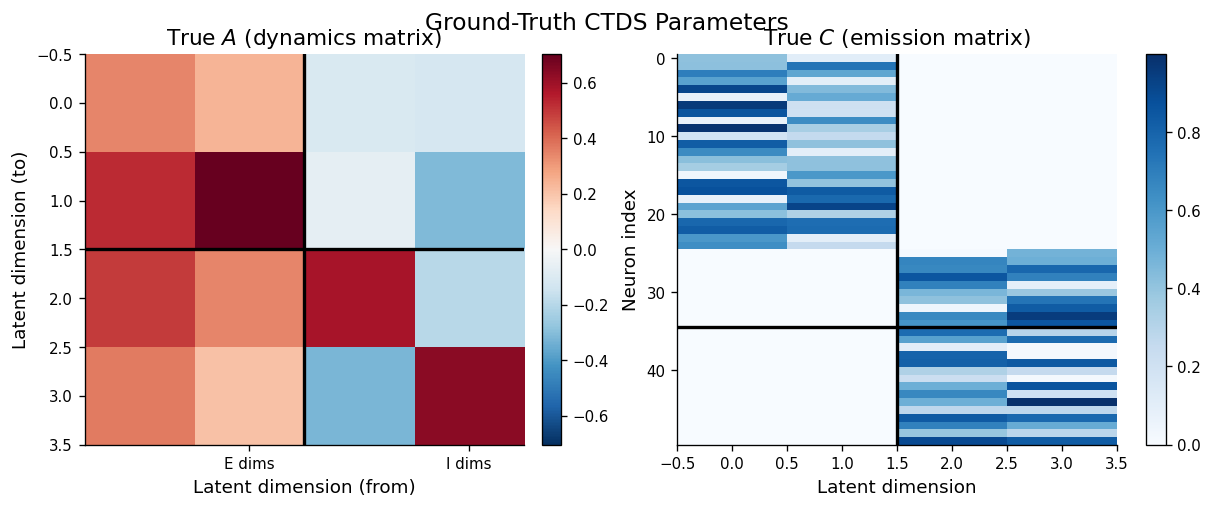

In [6]:
# Visualise ground-truth A and C
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# --- A_true ---
vmax_A = np.max(np.abs(A_viz))
im0 = axes[0].imshow(A_viz, cmap='RdBu_r', vmin=-vmax_A, vmax=vmax_A, aspect='auto')
draw_block_lines(axes[0], D_E_viz)
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
axes[0].set_title(r'True $A$ (dynamics matrix)')
axes[0].set_xlabel('Latent dimension (from)')
axes[0].set_ylabel('Latent dimension (to)')
axes[0].set_xticks([D_E_viz//2, D_E_viz + (D_DEFAULT-D_E_viz)//2])
axes[0].set_xticklabels(['E dims', 'I dims'])

# --- C_true ---
im1 = axes[1].imshow(C_viz, cmap='Blues', vmin=0, vmax=np.max(C_viz), aspect='auto')
draw_block_lines(axes[1], D_E_viz, N_E=N_E_DEFAULT)
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
axes[1].set_title(r'True $C$ (emission matrix)')
axes[1].set_xlabel('Latent dimension')
axes[1].set_ylabel('Neuron index')

fig.suptitle('Ground-Truth CTDS Parameters', fontsize=14, y=1.02)
save_figure(2, fig, 'section1_ground_truth_params', section=1)
plt.show()

## Section 2: Experiment 2.1 — Visual Parameter Recovery (Qualitative)

**Question:** Does the recovered parameter structure match the ground truth qualitatively?

**Hypothesis:** After alignment via `transform_true_rec`, the recovered A, C, Q, R matrices are visually similar to the ground truth. Specifically:
- The sign structure of A (excitatory vs. inhibitory columns) is preserved.
- The block-diagonal structure of C is recovered and zero padding is preserved exactly.
- Posterior mean latent trajectories track the true latent states within ±2 posterior standard deviations.



In [7]:
print("Running Experiment 2.1 (single seed, default configuration)...")
print(f"  T={T_DEFAULT}, B={B_DEFAULT}, D={D_DEFAULT}, N={N_DEFAULT}, iters={NUM_EM_ITERS}")

result_21 = run_em_single_seed(
    seed_key=jr.PRNGKey(1),
    T=T_DEFAULT, B=B_DEFAULT,
    D=D_DEFAULT, N_E=N_E_DEFAULT, N_I=N_I_DEFAULT,
    num_iters=NUM_EM_ITERS,
    verbose=False
)

errs_21   = result_21['errors']
tp_21     = result_21['true_params']
fp_21     = result_21['fitted_params']
ctds_21   = result_21['ctds_model']
A_true_21 = np.array(tp_21.dynamics.weights)
C_true_21 = np.array(tp_21.emissions.weights)
Q_true_21 = np.array(tp_21.dynamics.cov)
R_true_21 = np.array(tp_21.emissions.cov)
A_rec_21  = errs_21['_A_rec_al']
C_rec_21  = errs_21['_C_rec_al']
Q_rec_21  = errs_21['_Q_rec_al']
R_rec_21  = errs_21['_R_rec']
D_E_21    = int(tp_21.constraints.cell_type_dimensions[0])
N_E_21    = int(jnp.sum(tp_21.constraints.cell_type_mask == 0))

print("\nExperiment 2.1 Results:")
print(f"  epsilon_A:    {errs_21['epsilon_A']:.4f}")
print(f"  epsilon_C:    {errs_21['epsilon_C']:.4f}")
print(f"  epsilon_Q:    {errs_21['epsilon_Q']:.4f}")
print(f"  sign_match_A: {errs_21['sign_match_A']:.4f}  (1.0 = perfect)")

# Assertion checks
for metric, threshold, label in [
    ('epsilon_A',    1.0, 'complete failure'),
    ('epsilon_C',    1.0, 'complete failure'),
    ('sign_match_A', 0.5, 'below chance level'),
]:
    val = errs_21[metric]
    cond = val < threshold if metric != 'sign_match_A' else val > threshold
    try:
        assert cond, f"{metric}={val:.4f} is {label}"
    except AssertionError as e:
        print(f"WARNING: {e}")

Running Experiment 2.1 (single seed, default configuration)...
  T=500, B=10, D=4, N=50, iters=100
Y shape (5000, 50)
Iteration 1: ll=-23.7245993834691  rel_change=0.014139020360867359
Iteration 2: ll=-22.49743111064401  rel_change=0.051725563538078605
Iteration 3: ll=-22.360939830482838  rel_change=0.006066971801797937
Iteration 4: ll=-22.34751807071966  rel_change=0.0006002323634394587
Iteration 5: ll=-22.34322636310953  rel_change=0.00019204403802456827
Iteration 6: ll=-22.340832080979023  rel_change=0.00010715919409290141
Iteration 7: ll=-22.339015123800188  rel_change=8.132898417784858e-05
Iteration 8: ll=-22.337433935797353  rel_change=7.078145540761753e-05
Iteration 9: ll=-22.335981630688714  rel_change=6.501664930774042e-05
Iteration 10: ll=-22.334636712235366  rel_change=6.021308915751468e-05
Iteration 11: ll=-22.333426048336587  rel_change=5.420566783231774e-05
Iteration 12: ll=-22.332336145534157  rel_change=4.8801415424154524e-05
Iteration 13: ll=-22.331295954333225  rel_ch

  Saved: Experiment Group 2/Section 2/exp2_1a_A_matrix.png


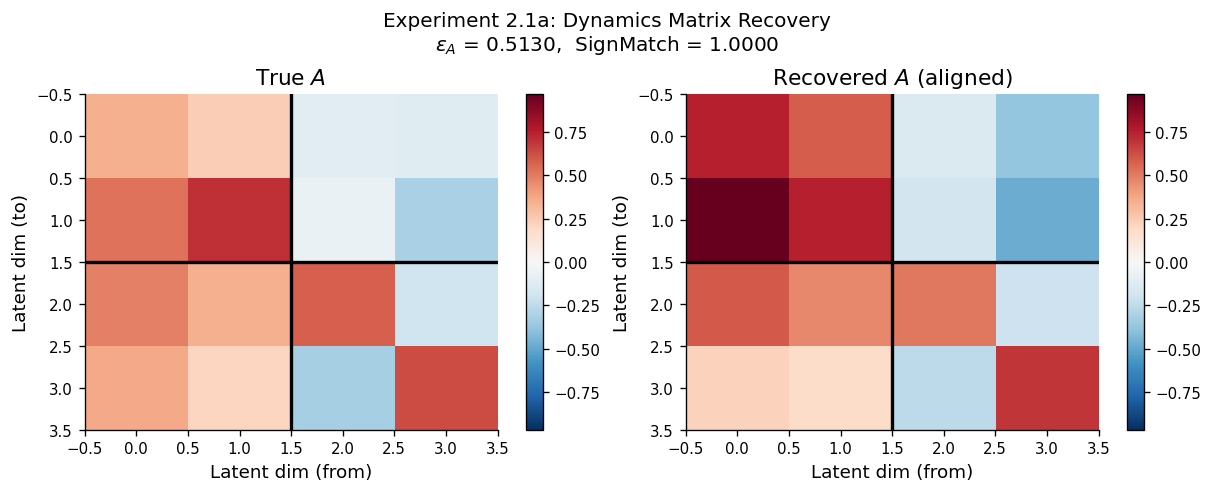

In [8]:
# ── Plot 2.1.a — Dynamics matrix A (1×2 panel) ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
vmax_A = max(np.max(np.abs(A_true_21)), np.max(np.abs(A_rec_21)))

for ax, mat, title in zip(axes, [A_true_21, A_rec_21], [r'True $A$', r'Recovered $A$ (aligned)']):
    im = ax.imshow(mat, cmap='RdBu_r', vmin=-vmax_A, vmax=vmax_A, aspect='auto')
    draw_block_lines(ax, D_E_21)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title)
    ax.set_xlabel('Latent dim (from)')
    ax.set_ylabel('Latent dim (to)')

fig.suptitle(
    f'Experiment 2.1a: Dynamics Matrix Recovery\n'
    f'$\\epsilon_A$ = {errs_21["epsilon_A"]:.4f},  '
    f'SignMatch = {errs_21["sign_match_A"]:.4f}',
    fontsize=12
)
save_figure(2, fig, 'exp2_1a_A_matrix', section=2)
plt.show()

  Saved: Experiment Group 2/Section 2/exp2_1b_C_matrix.png


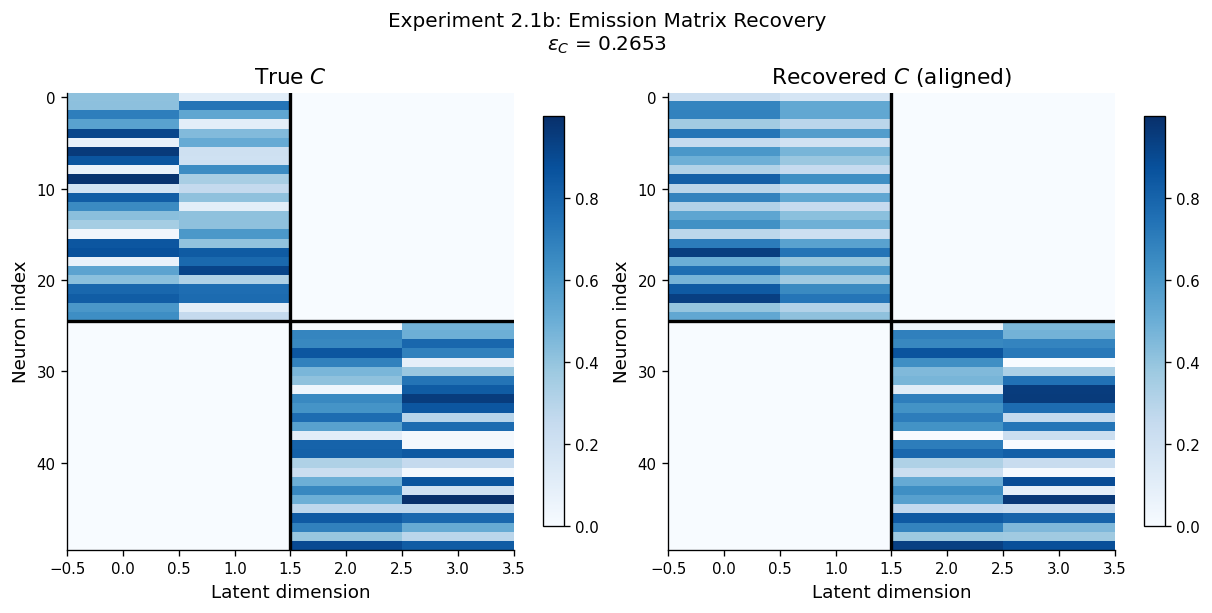

In [9]:
# ── Plot 2.1.b — Emission matrix C (1×2 panel) ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
vmax_C = max(np.max(C_true_21), np.max(C_rec_21))

for ax, mat, title in zip(axes, [C_true_21, C_rec_21], [r'True $C$', r'Recovered $C$ (aligned)']):
    im = ax.imshow(mat, cmap='Blues', vmin=0, vmax=vmax_C, aspect='auto')
    draw_block_lines(ax, D_E_21, N_E=N_E_21)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title)
    ax.set_xlabel('Latent dimension')
    ax.set_ylabel('Neuron index')

fig.suptitle(
    f'Experiment 2.1b: Emission Matrix Recovery\n'
    f'$\\epsilon_C$ = {errs_21["epsilon_C"]:.4f}',
    fontsize=12
)
save_figure(2, fig, 'exp2_1b_C_matrix', section=2)
plt.show()

  Saved: Experiment Group 2/Section 2/exp2_1c_covariances.png


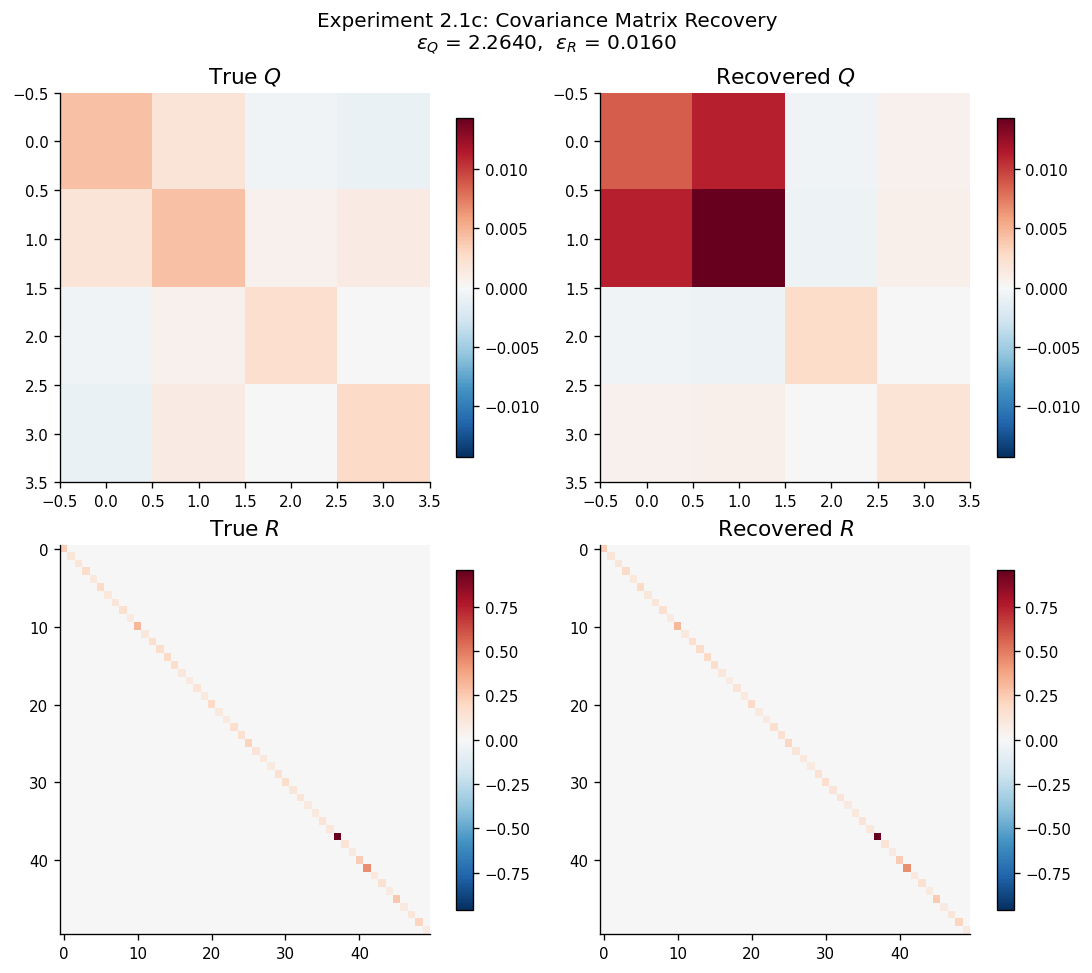

In [10]:
# ── Plot 2.1.c — Covariance matrices (2×2 grid) ───────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(9, 8))

vmax_Q = max(np.max(np.abs(Q_true_21)), np.max(np.abs(Q_rec_21)))
vmax_R = max(np.max(np.abs(R_true_21)), np.max(np.abs(R_rec_21)))

pairs = [
    (axes[0,0], Q_true_21, r'True $Q$',          'RdBu_r', vmax_Q),
    (axes[0,1], Q_rec_21,  r'Recovered $Q$',      'RdBu_r', vmax_Q),
    (axes[1,0], R_true_21, r'True $R$',           'RdBu_r', vmax_R),
    (axes[1,1], R_rec_21,  r'Recovered $R$',      'RdBu_r', vmax_R),
]
for ax, mat, title, cmap, vmax in pairs:
    im = ax.imshow(mat, cmap=cmap, vmin=-vmax, vmax=vmax, aspect='auto')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title)

fig.suptitle(
    f'Experiment 2.1c: Covariance Matrix Recovery\n'
    f'$\\epsilon_Q$ = {errs_21["epsilon_Q"]:.4f},  '
    f'$\\epsilon_R$ = {errs_21["epsilon_R"]:.4f}',
    fontsize=12
)
save_figure(2, fig, 'exp2_1c_covariances', section=2)
plt.show()

  Saved: Experiment Group 2/Section 2/exp2_1d_latent_trajectories.png


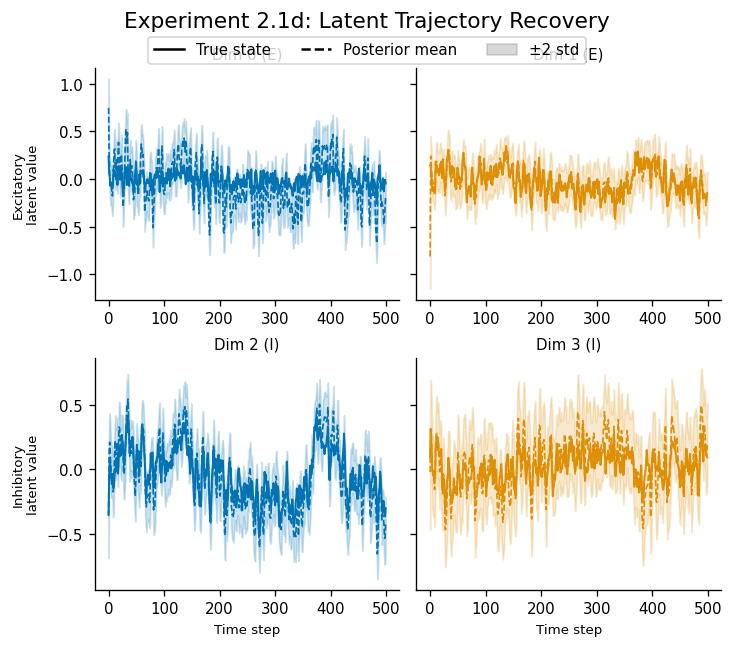


Experiment 2.1 complete.
  epsilon_A:    0.5130
  epsilon_C:    0.2653
  epsilon_Q:    2.2640
  sign_match_A: 1.0000  (1.0 = perfect sign recovery)


In [11]:
# ── Plot 2.1.d — Latent trajectory comparison ──────────────────────────────────
# Compute posterior smoothed means and covariances for first training trial
obs_0 = result_21['batch_observations'][0]  # (T, N)
inp_0 = jnp.zeros((T_DEFAULT, 0))
smoothed_means, smoothed_covs = ctds_21.smoother(fp_21, obs_0, inp_0)
# smoothed_means: (T, D), smoothed_covs: (T, D, D)
true_states_0 = np.array(result_21['batch_states'][0])  # (T, D)
sm_means = np.array(smoothed_means)
sm_stds  = np.sqrt(np.array(smoothed_covs[:, np.arange(D_DEFAULT), np.arange(D_DEFAULT)]))
# sm_stds shape: (T, D)

t_axis = np.arange(T_DEFAULT)
D_E = D_E_21
D_I = D_DEFAULT - D_E

fig, axes = plt.subplots(2, max(D_E, D_I), figsize=(3 * max(D_E, D_I), 5), sharey='row')
if max(D_E, D_I) == 1:
    axes = axes[:, np.newaxis]

colours = PALETTE
legend_handles = [
    mlines.Line2D([], [], color='k', linestyle='-',  label='True state'),
    mlines.Line2D([], [], color='k', linestyle='--', label='Posterior mean'),
    mpatches.Patch(color='grey', alpha=0.3, label='±2 std'),
]

for row, (start, stop, label) in enumerate([(0, D_E, 'Excitatory'), (D_E, D_DEFAULT, 'Inhibitory')]):
    for col_idx, d in enumerate(range(start, stop)):
        ax = axes[row, col_idx]
        c  = colours[col_idx % len(colours)]
        ax.plot(t_axis, true_states_0[:, d], color=c, lw=1.2, linestyle='-')
        ax.plot(t_axis, sm_means[:, d],      color=c, lw=1.0, linestyle='--')
        ax.fill_between(
            t_axis,
            sm_means[:, d] - 2*sm_stds[:, d],
            sm_means[:, d] + 2*sm_stds[:, d],
            color=c, alpha=0.2
        )
        ax.set_title(f'Dim {d} ({label[0]})', fontsize=9)
        if col_idx == 0:
            ax.set_ylabel(f'{label}\nlatent value', fontsize=8)
        if row == 1:
            ax.set_xlabel('Time step', fontsize=8)
    # Hide unused axes in this row
    n_dims = stop - start
    for col_idx in range(n_dims, max(D_E, D_I)):
        axes[row, col_idx].set_visible(False)

fig.legend(handles=legend_handles, loc='upper center', ncol=3,
           bbox_to_anchor=(0.5, 1.02), fontsize=9)
fig.suptitle('Experiment 2.1d: Latent Trajectory Recovery', fontsize=13, y=1.05)
save_figure(2, fig, 'exp2_1d_latent_trajectories', section=2)
plt.show()

print("\nExperiment 2.1 complete.")
print(f"  epsilon_A:    {errs_21['epsilon_A']:.4f}")
print(f"  epsilon_C:    {errs_21['epsilon_C']:.4f}")
print(f"  epsilon_Q:    {errs_21['epsilon_Q']:.4f}")
print(f"  sign_match_A: {errs_21['sign_match_A']:.4f}  (1.0 = perfect sign recovery)")

## Section 3: Experiment 2.2 — Recovery Error vs. Data Volume

**Question:** How does parameter recovery error scale with total data T·B?

**Hypothesis:** Recovery errors decrease as O(1/√(T·B)), consistent with Cramér-Rao scaling for a correctly specified model. T and B should be approximately exchangeable: varying T with B fixed and varying B with T fixed should produce the same effective scaling.



In [ ]:
T_VALUES = [50, 100, 200, 500, 1000, 2000]
#T_VALUES = [50, 100, 200]
B_VALUES = [1, 2, 5, 10, 100,1000]
B_FIXED_22 = 5
T_FIXED_22 = 500

seed_keys_22 = jr.split(jr.PRNGKey(22), NUM_SEEDS)

# Sub-protocol A: vary T
print("Experiment 2.2 Sub-protocol A: Varying T (B=5 fixed)")
results_22A = {}  # T -> list of error dicts
for T_val in T_VALUES:
    errs_list = []
    for i, sk in enumerate(seed_keys_22):
        r = run_em_single_seed(
            seed_key=jr.fold_in(sk, T_val),
            T=T_val, B=B_FIXED_22,
            D=D_DEFAULT, N_E=N_E_DEFAULT, N_I=N_I_DEFAULT,
            num_iters=NUM_EM_ITERS
        )
        errs_list.append(r['errors'])
        print(f"  T={T_val:4d}, seed {i+1}/{NUM_SEEDS}: "
              f"ε_A={r['errors']['epsilon_A']:.4f}", flush=True)
    results_22A[T_val] = errs_list

print("\nSub-protocol A complete.")

Experiment 2.2 Sub-protocol A: Varying T (B=5 fixed)
Y shape (250, 50)


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/dynamax/linear_gaussian_ssm/inference.py:182: UserWarning: Emission covariance has shape (N,N) where N is the number of timesteps. The covariance will be interpreted as static and non-diagonal. To specify a dynamic and diagonal covariance, pass it as a 3D array.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/dynamax/linear_gaussian_ssm/inference.py:182: UserWarning: Emission covariance has shape (N,N) where N is the number of timesteps. The covariance will be interpreted as static and non-diagonal. To specify a dynamic and diagonal covariance, pass it as a 3D array.
  warnings.warn(


Iteration 1: ll=-23.47537060476887  rel_change=0.09315685605956972
Iteration 2: ll=-22.61277053551497  rel_change=0.03674489675910254
Iteration 3: ll=-22.529258231544265  rel_change=0.003693147809532798
Iteration 4: ll=-22.49591105863029  rel_change=0.00148017180908697
Iteration 5: ll=-22.47631631777911  rel_change=0.000871035665108878
Iteration 6: ll=-22.462748901920072  rel_change=0.0006036316479628416
Iteration 7: ll=-22.452555652001873  rel_change=0.0004537846174885531
Iteration 8: ll=-22.444426557563666  rel_change=0.0003620565321917213
Iteration 9: ll=-22.437636941445927  rel_change=0.00030250788989090417
Iteration 10: ll=-22.431727320324192  rel_change=0.00026337983528102425
Iteration 11: ll=-22.426671172015624  rel_change=0.0002254016481373374
Iteration 12: ll=-22.422470093463048  rel_change=0.00018732510591317673
Iteration 13: ll=-22.41893962220146  rel_change=0.00015745237910331892
Iteration 14: ll=-22.41589799167939  rel_change=0.00013567236333769095
Iteration 15: ll=-22.413

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/dynamax/linear_gaussian_ssm/inference.py:182: UserWarning: Emission covariance has shape (N,N) where N is the number of timesteps. The covariance will be interpreted as static and non-diagonal. To specify a dynamic and diagonal covariance, pass it as a 3D array.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/dynamax/linear_gaussian_ssm/inference.py:182: UserWarning: Emission covariance has shape (N,N) where N is the number of timesteps. The covariance will be interpreted as static and non-diagonal. To specify a dynamic and diagonal covariance, pass it as a 3D array.
  warnings.warn(


Iteration 1: ll=-23.119382677074796  rel_change=0.0902500615044534
Iteration 2: ll=-22.623169016115916  rel_change=0.021463101670570334
Iteration 3: ll=-22.530425782168663  rel_change=0.0040994802222971815
Iteration 4: ll=-22.500359419769154  rel_change=0.0013344782158225185
Iteration 5: ll=-22.487050293874585  rel_change=0.0005915072575629676
Iteration 6: ll=-22.477904594569445  rel_change=0.00040670960333248824
Iteration 7: ll=-22.47054685121279  rel_change=0.0003273322620307863
Iteration 8: ll=-22.464334381324296  rel_change=0.00027647168222619733
Iteration 9: ll=-22.45882843756924  rel_change=0.00024509712425001436
Iteration 10: ll=-22.45402038560666  rel_change=0.00021408293740453826
Iteration 11: ll=-22.449846881221895  rel_change=0.0001858689140339161
Iteration 12: ll=-22.446159917094413  rel_change=0.00016423114807808916
Iteration 13: ll=-22.44284231521551  rel_change=0.00014780264825493033
Iteration 14: ll=-22.439820353377822  rel_change=0.00013465147574647887
Iteration 15: ll

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/dynamax/linear_gaussian_ssm/inference.py:182: UserWarning: Emission covariance has shape (N,N) where N is the number of timesteps. The covariance will be interpreted as static and non-diagonal. To specify a dynamic and diagonal covariance, pass it as a 3D array.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/dynamax/linear_gaussian_ssm/inference.py:182: UserWarning: Emission covariance has shape (N,N) where N is the number of timesteps. The covariance will be interpreted as static and non-diagonal. To specify a dynamic and diagonal covariance, pass it as a 3D array.
  warnings.warn(


Iteration 1: ll=-23.697270555392954  rel_change=0.043306156779619034
Iteration 2: ll=-22.466458449034146  rel_change=0.05193898189590046
Iteration 3: ll=-22.283294307754513  rel_change=0.008152782143885557
Iteration 4: ll=-22.244594262493568  rel_change=0.001736729081726406
Iteration 5: ll=-22.223260577169874  rel_change=0.0009590503235055592
Iteration 6: ll=-22.206813804965446  rel_change=0.000740070168700868
Iteration 7: ll=-22.194250756164617  rel_change=0.0005657294608387282
Iteration 8: ll=-22.18517197089494  rel_change=0.0004090602277778191
Iteration 9: ll=-22.178402938581243  rel_change=0.00030511516081907795
Iteration 10: ll=-22.17292234648765  rel_change=0.00024711392018494195
Iteration 11: ll=-22.16820324937153  rel_change=0.0002128315357973356
Iteration 12: ll=-22.164087244897306  rel_change=0.00018567154170873285
Iteration 13: ll=-22.16052667692132  rel_change=0.00016064582026973032
Iteration 14: ll=-22.157475805833183  rel_change=0.0001376714160550952
Iteration 15: ll=-22.

In [13]:
# Sub-protocol B: vary B
print("Experiment 2.2 Sub-protocol B: Varying B (T=500 fixed)")
results_22B = {}  # B -> list of error dicts
for B_val in B_VALUES:
    errs_list = []
    for i, sk in enumerate(seed_keys_22):
        r = run_em_single_seed(
            seed_key=jr.fold_in(sk, B_val + 10000),  # distinct fold from sub-A
            T=T_FIXED_22, B=B_val,
            D=D_DEFAULT, N_E=N_E_DEFAULT, N_I=N_I_DEFAULT,
            num_iters=NUM_EM_ITERS
        )
        errs_list.append(r['errors'])
        print(f"  B={B_val:3d}, seed {i+1}/{NUM_SEEDS}: "
              f"ε_A={r['errors']['epsilon_A']:.4f}", flush=True)
    results_22B[B_val] = errs_list

print("\nSub-protocol B complete.")

Experiment 2.2 Sub-protocol B: Varying B (T=500 fixed)
Y shape (500, 50)
Iteration 1: ll=-23.745351120630705  rel_change=0.012273333514568625
Iteration 2: ll=-22.648931000618827  rel_change=0.04617409590794689
Iteration 3: ll=-22.312317238241043  rel_change=0.014862236207465513
Iteration 4: ll=-22.274236338772297  rel_change=0.001706720958748192
Iteration 5: ll=-22.259172971625432  rel_change=0.0006762686234340684
Iteration 6: ll=-22.244239112150566  rel_change=0.0006709081012984629
Iteration 7: ll=-22.228313255376847  rel_change=0.0007159542159849452
Iteration 8: ll=-22.214744965517607  rel_change=0.0006104057335955626
Iteration 9: ll=-22.204870293203026  rel_change=0.0004445098212880441
Iteration 10: ll=-22.1979926001851  rel_change=0.0003097380406690625
Iteration 11: ll=-22.192918393181895  rel_change=0.00022858855278477396
Iteration 12: ll=-22.18895571954512  rel_change=0.00017855577020424234
Iteration 13: ll=-22.185717655943673  rel_change=0.00014593132017446693
Iteration 14: ll=-

KeyboardInterrupt: 

In [ ]:
# Aggregate statistics for 2.2
def aggregate_errors(results_dict, key_list):
    """Compute mean and SE across seeds for each metric and each condition."""
    means = {k: {} for k in ['epsilon_A', 'epsilon_C', 'epsilon_Q']}
    ses   = {k: {} for k in ['epsilon_A', 'epsilon_C', 'epsilon_Q']}
    for cond, errs_list in results_dict.items():
        for metric in ['epsilon_A', 'epsilon_C', 'epsilon_Q']:
            vals = np.array([e[metric] for e in errs_list])
            means[metric][cond] = np.mean(vals)
            ses[metric][cond]   = np.std(vals, ddof=1) / np.sqrt(len(vals))
    return means, ses

means_A, ses_A = aggregate_errors(results_22A, T_VALUES)
means_B, ses_B = aggregate_errors(results_22B, B_VALUES)

# Compute log-log slopes for epsilon_A
log_T   = np.log(T_VALUES)
log_eA_T = np.log([means_A['epsilon_A'][T] for T in T_VALUES])
slope_T  = np.polyfit(log_T, log_eA_T, 1)[0]

log_B   = np.log(B_VALUES)
log_eA_B = np.log([means_B['epsilon_A'][B] for B in B_VALUES])
slope_B  = np.polyfit(log_B, log_eA_B, 1)[0]

print(f"Empirical log-log slope (ε_A vs T): {slope_T:.3f}  (theory: -0.500)")
print(f"Empirical log-log slope (ε_A vs B): {slope_B:.3f}  (theory: -0.500)")

Empirical log-log slope (ε_A vs T): -0.239  (theory: -0.500)
Empirical log-log slope (ε_A vs B): -0.169  (theory: -0.500)


  Saved: Experiment Group 2/Section 3/exp2_2a_error_vs_T.png


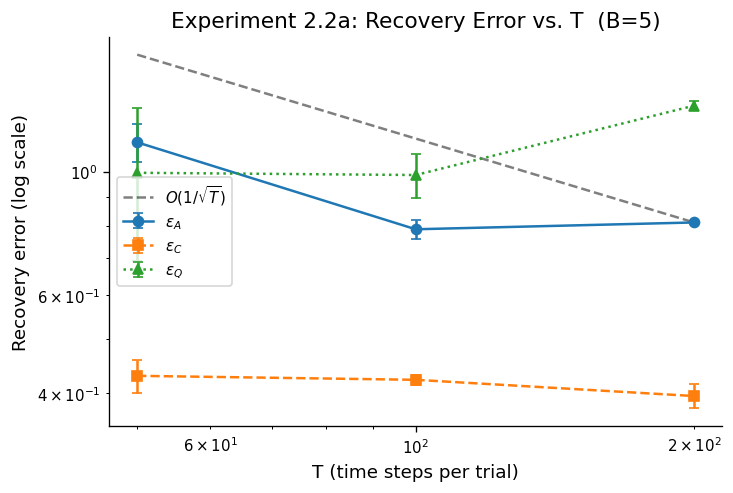

In [ ]:
# ── Plot 2.2.a — Recovery error vs. T ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))

styles = [('-', 'o'), ('--', 's'), (':', '^')]
for (metric, label), (ls, marker) in zip(
    [('epsilon_A', r'$\epsilon_A$'), ('epsilon_C', r'$\epsilon_C$'), ('epsilon_Q', r'$\epsilon_Q$')],
    styles
):
    ys   = [means_A[metric][T] for T in T_VALUES]
    errs = [ses_A[metric][T]   for T in T_VALUES]
    ax.errorbar(T_VALUES, ys, yerr=errs, label=label,
                linestyle=ls, marker=marker, capsize=3)

# Reference line O(1/sqrt(T)) anchored at default T=500
anchor_T   = 200
anchor_val = means_A['epsilon_A'][anchor_T] if anchor_T in means_A['epsilon_A'] else means_A['epsilon_A'][T_VALUES[3]]
ref_T  = np.array(T_VALUES)
ref_y  = anchor_val * np.sqrt(anchor_T / ref_T)
ax.plot(ref_T, ref_y, 'k--', alpha=0.5, linewidth=1.5, label=r'$O(1/\sqrt{T})$')

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('T (time steps per trial)')
ax.set_ylabel('Recovery error (log scale)')
ax.set_title(f'Experiment 2.2a: Recovery Error vs. T  (B={B_FIXED_22})')
ax.legend()
save_figure(2, fig, 'exp2_2a_error_vs_T', section=3)
plt.show()

  Saved: Experiment Group 2/Section 3/exp2_2b_error_vs_B.png


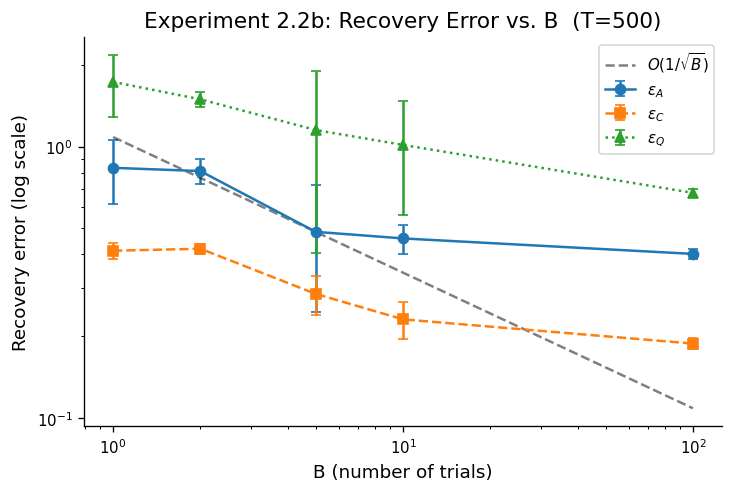

In [ ]:
# ── Plot 2.2.b — Recovery error vs. B ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))

for (metric, label), (ls, marker) in zip(
    [('epsilon_A', r'$\epsilon_A$'), ('epsilon_C', r'$\epsilon_C$'), ('epsilon_Q', r'$\epsilon_Q$')],
    styles
):
    ys   = [means_B[metric][B] for B in B_VALUES]
    errs = [ses_B[metric][B]   for B in B_VALUES]
    ax.errorbar(B_VALUES, ys, yerr=errs, label=label,
                linestyle=ls, marker=marker, capsize=3)

anchor_B   = 5
anchor_val_B = means_B['epsilon_A'][anchor_B] if anchor_B in means_B['epsilon_A'] else means_B['epsilon_A'][B_VALUES[2]]
ref_B  = np.array(B_VALUES)
ref_y_B = anchor_val_B * np.sqrt(anchor_B / ref_B)
ax.plot(ref_B, ref_y_B, 'k--', alpha=0.5, linewidth=1.5, label=r'$O(1/\sqrt{B})$')

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('B (number of trials)')
ax.set_ylabel('Recovery error (log scale)')
ax.set_title(f'Experiment 2.2b: Recovery Error vs. B  (T={T_FIXED_22})')
ax.legend()
save_figure(2, fig, 'exp2_2b_error_vs_B', section=3)
plt.show()

  Saved: Experiment Group 2/Section 3/exp2_2c_error_vs_TB.png


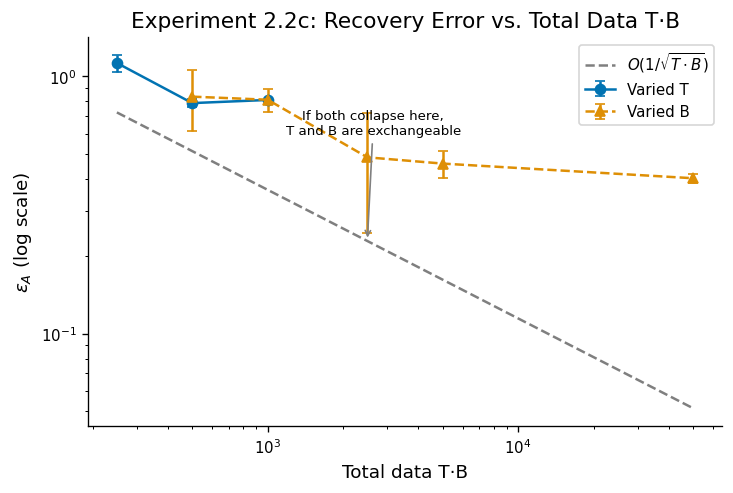


Experiment 2.2 Summary
  Empirical scaling exponent (ε_A vs T): -0.239  (theory: -0.500)
  Empirical scaling exponent (ε_A vs B): -0.169  (theory: -0.500)
  T and B approximately exchangeable:    True


In [ ]:
# ── Plot 2.2.c — Combined T·B plot ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))

# Varied-T points
TB_varT = np.array([T * B_FIXED_22 for T in T_VALUES])
eA_varT = np.array([means_A['epsilon_A'][T] for T in T_VALUES])
se_varT = np.array([ses_A['epsilon_A'][T]   for T in T_VALUES])
ax.errorbar(TB_varT, eA_varT, yerr=se_varT,
            color=PALETTE[0], marker='o', linestyle='-',
            label='Varied T', capsize=3)

# Varied-B points
TB_varB = np.array([T_FIXED_22 * B for B in B_VALUES])
eA_varB = np.array([means_B['epsilon_A'][B] for B in B_VALUES])
se_varB = np.array([ses_B['epsilon_A'][B]   for B in B_VALUES])
ax.errorbar(TB_varB, eA_varB, yerr=se_varB,
            color=PALETTE[1], marker='^', linestyle='--',
            label='Varied B', capsize=3)

# Reference line anchored at default T=500, B=5
anchor_TB  = 200
all_TB     = np.sort(np.unique(np.concatenate([TB_varT, TB_varB])))
#anchor_eA  = means_A['epsilon_A'].get(T_FIXED_22, list(means_A['epsilon_A'].values())[3])
anchor_eA = means_A['epsilon_A'][200]
ref_line   = anchor_eA * np.sqrt(anchor_TB / all_TB)
ax.plot(all_TB, ref_line, 'k--', alpha=0.5, linewidth=1.5,
        label=r'$O(1/\sqrt{T \cdot B})$')
ax.annotate(
    'If both collapse here,\nT and B are exchangeable',
    xy=(all_TB[len(all_TB)//2], ref_line[len(all_TB)//2]),
    xytext=(0.45, 0.75), textcoords='axes fraction',
    fontsize=8, ha='center',
    arrowprops=dict(arrowstyle='->', color='grey')
)

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Total data T·B')
ax.set_ylabel(r'$\epsilon_A$ (log scale)')
ax.set_title('Experiment 2.2c: Recovery Error vs. Total Data T·B')
ax.legend()
save_figure(2, fig, 'exp2_2c_error_vs_TB', section=3)
plt.show()

print("\nExperiment 2.2 Summary")
print(f"  Empirical scaling exponent (ε_A vs T): {slope_T:.3f}  (theory: -0.500)")
print(f"  Empirical scaling exponent (ε_A vs B): {slope_B:.3f}  (theory: -0.500)")
exchangeable = abs(slope_T - slope_B) < 0.15
print(f"  T and B approximately exchangeable:    {exchangeable}")

## Section 4: Experiment 2.3 — Recovery Error vs. Signal-to-Noise Ratio

**Question:** How does recovery error depend on the signal-to-noise ratio?

**Hypothesis:** Recovery degrades  as SNR decreases, with a phase transition at very low SNR (< 0.3) where recovery fails entirely. Posterior uncertainty grows as SNR falls; the model is appropriately calibrated about its uncertainty.

**SNR definition:** SNR = ‖C Σ_∞ C^T‖_F / ‖R‖_F, where Σ_∞ satisfies the discrete Lyapunov equation.


In [ ]:
TARGET_SNRS = [0.1, 0.3, 1.0, 3.0, 10.0]
seed_keys_23 = jr.split(jr.PRNGKey(23), NUM_SEEDS)

results_23 = {}   # target_snr -> list of dicts

print("Experiment 2.3: Varying SNR")
for target_snr in TARGET_SNRS:
    run_results = []
    for i, sk in enumerate(seed_keys_23):
        # Step 1: generate ground-truth params
        _, _, ctds_snr, tp_snr = generate_synthetic_data(
            num_samples=1, num_timesteps=T_DEFAULT,
            state_dim=D_DEFAULT, emission_dim=N_DEFAULT,
            cell_types=K, key=jr.fold_in(sk, int(target_snr * 100))
        )

        # Step 2: compute current SNR and scale R to hit target
        current_snr = compute_snr(
            np.array(tp_snr.emissions.weights),
            np.array(tp_snr.dynamics.weights),
            np.array(tp_snr.dynamics.cov),
            np.array(tp_snr.emissions.cov)
        )
        # EXPLANATION: Scale R so that the resulting SNR matches target_snr.
        # current_snr = signal / ||R||, so to get target_snr we need
        # ||R_new|| = signal / target_snr = ||R|| * (current_snr / target_snr).
        R_scaled = tp_snr.emissions.cov * (current_snr / target_snr)

        # Step 3: build modified params with scaled R
        new_emissions = tp_snr.emissions._replace(cov=R_scaled)
        tp_modified   = tp_snr._replace(emissions=new_emissions)

        # Step 4: sample B trials from modified model
        trial_keys = jr.split(jr.fold_in(sk, 999), B_DEFAULT)
        obs_list = [ctds_snr.sample(tp_modified, k, T_DEFAULT)[1] for k in trial_keys]
        batch_obs = jnp.stack(obs_list)

        # Step 5: run EM
        batch_inp = jnp.zeros((B_DEFAULT, T_DEFAULT, 0))
        init_p    = ctds_snr.initialize(batch_obs)
        # Replace R in init to reflect modified model scale
        init_p = init_p._replace(emissions=init_p.emissions._replace(cov=R_scaled))
        fitted_p, _ = ctds_snr.fit_em(
            init_p, batch_obs, batch_inp, NUM_EM_ITERS,
        )

        # Step 6: compute errors (using modified true params)
        errors = align_and_compute_errors(tp_modified, fitted_p)

        # Step 7: compute posterior uncertainty
        sm_means_snr, sm_covs_snr = ctds_snr.smoother(fitted_p, batch_obs[0],
                                                        jnp.zeros((T_DEFAULT, 0)))
        diag_stds = jnp.sqrt(sm_covs_snr[:, jnp.arange(D_DEFAULT), jnp.arange(D_DEFAULT)])
        mean_post_std = float(jnp.mean(diag_stds))

        actual_snr = compute_snr(
            np.array(tp_modified.emissions.weights),
            np.array(tp_modified.dynamics.weights),
            np.array(tp_modified.dynamics.cov),
            np.array(tp_modified.emissions.cov)
        )

        run_results.append({
            'errors': errors,
            'mean_post_std': mean_post_std,
            'actual_snr': actual_snr,
        })
        print(f"  SNR={target_snr:.1f}, seed {i+1}/{NUM_SEEDS}: "
              f"ε_A={errors['epsilon_A']:.4f}, post_std={mean_post_std:.4f}", flush=True)

    results_23[target_snr] = run_results

print("\nExperiment 2.3 data collection complete.")

Experiment 2.3: Varying SNR
Y shape (5000, 50)
Iteration 1: ll=-51.7542771399184  rel_change=0.0006896002633865628
Iteration 2: ll=-51.724594299859994  rel_change=0.000573534047788165
Iteration 3: ll=-51.6757280661879  rel_change=0.0009447388487728563
Iteration 4: ll=-51.52550683435792  rel_change=0.0029069978779509707
Iteration 5: ll=-51.3223562391265  rel_change=0.00394271900875236
Iteration 6: ll=-51.26658775350032  rel_change=0.0010866314353601032
Iteration 7: ll=-51.25508481993147  rel_change=0.00022437486232078515
Iteration 8: ll=-51.24984953244726  rel_change=0.00010214181680908162
Iteration 9: ll=-51.24665323652413  rel_change=6.23669328259161e-05
Iteration 10: ll=-51.244441669423054  rel_change=4.315534696228236e-05
Iteration 11: ll=-51.24278580972079  rel_change=3.23129621148526e-05
Iteration 12: ll=-51.24148269570668  rel_change=2.543019458293836e-05
Iteration 13: ll=-51.24042471932899  rel_change=2.0646872846508604e-05
Iteration 14: ll=-51.239553358089005  rel_change=1.7005

  Saved: Experiment Group 2/Section 4/exp2_3a_error_vs_SNR.png


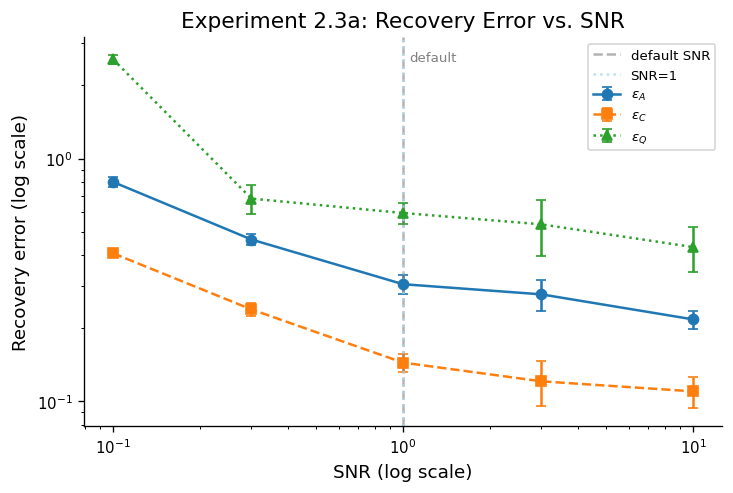

  Saved: Experiment Group 2/Section 4/exp2_3b_posterior_uncertainty_vs_SNR.png


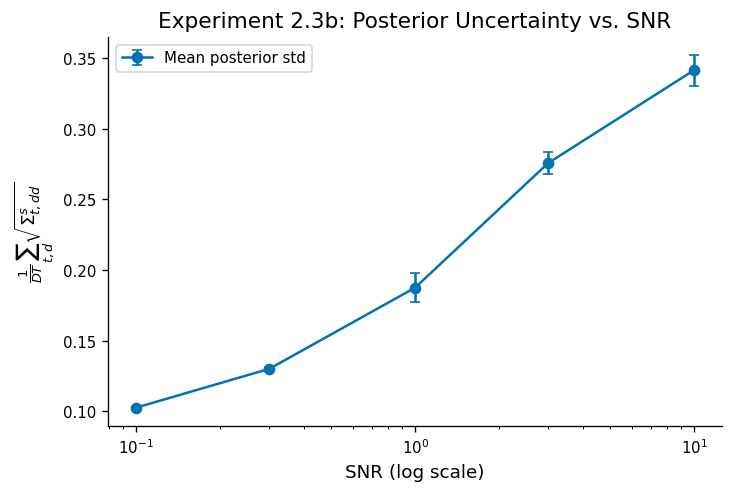


Experiment 2.3 Summary
  SNR range tested:         0.10 -- 10.00
  ε_A at lowest SNR:        0.8007  (expected ~1.0)
  ε_A at highest SNR:       0.2176  (expected <0.1)
  Phase transition near SNR: 0.20000000000000004


In [ ]:
# Aggregate 2.3 statistics
def agg23(results_23, metric):
    means_out, ses_out, snr_means = {}, {}, {}
    for snr, runs in results_23.items():
        if metric == 'mean_post_std':
            vals = np.array([r['mean_post_std'] for r in runs])
        else:
            vals = np.array([r['errors'][metric] for r in runs])
        means_out[snr] = np.mean(vals)
        ses_out[snr]   = np.std(vals, ddof=1) / np.sqrt(len(vals))
        snr_means[snr] = np.mean([r['actual_snr'] for r in runs])
    return means_out, ses_out, snr_means

m_eA_23, se_eA_23, snr_act_23 = agg23(results_23, 'epsilon_A')
m_eC_23, se_eC_23, _           = agg23(results_23, 'epsilon_C')
m_eQ_23, se_eQ_23, _           = agg23(results_23, 'epsilon_Q')
m_ps_23, se_ps_23, _           = agg23(results_23, 'mean_post_std')

snr_x = [snr_act_23[s] for s in TARGET_SNRS]

# ── Plot 2.3.a — Recovery error vs. SNR ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))

for metric, label, ls, marker in [
    ('epsilon_A', r'$\epsilon_A$', '-',  'o'),
    ('epsilon_C', r'$\epsilon_C$', '--', 's'),
    ('epsilon_Q', r'$\epsilon_Q$', ':',  '^'),
]:
    ys   = [m_eA_23[s] if metric == 'epsilon_A' else
             m_eC_23[s] if metric == 'epsilon_C' else m_eQ_23[s]
             for s in TARGET_SNRS]
    errs = [se_eA_23[s] if metric == 'epsilon_A' else
             se_eC_23[s] if metric == 'epsilon_C' else se_eQ_23[s]
             for s in TARGET_SNRS]
    ax.errorbar(snr_x, ys, yerr=errs, label=label,
                linestyle=ls, marker=marker, capsize=3)

# Mark default SNR (target=1.0)
ax.axvline(x=snr_act_23[1.0], color='grey', linestyle='--', alpha=0.6, label='default SNR')
ax.text(snr_act_23[1.0]*1.05, ax.get_ylim()[1]*0.9, 'default', fontsize=8, color='grey')
ax.axvline(x=1.0, color='lightblue', linestyle=':', alpha=0.8, label='SNR=1')

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('SNR (log scale)')
ax.set_ylabel('Recovery error (log scale)')
ax.set_title('Experiment 2.3a: Recovery Error vs. SNR')
ax.legend(fontsize=8)
save_figure(2, fig, 'exp2_3a_error_vs_SNR', section=4)
plt.show()

# ── Plot 2.3.b — Posterior uncertainty vs. SNR ────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))

ys_ps   = [m_ps_23[s] for s in TARGET_SNRS]
errs_ps = [se_ps_23[s] for s in TARGET_SNRS]
ax.errorbar(snr_x, ys_ps, yerr=errs_ps,
            color=PALETTE[0], marker='o', linestyle='-',
            capsize=3, label='Mean posterior std')

ax.set_xscale('log')
ax.set_xlabel('SNR (log scale)')
ax.set_ylabel(r'$\frac{1}{DT}\sum_{t,d}\sqrt{\Sigma^s_{t,dd}}$')
ax.set_title('Experiment 2.3b: Posterior Uncertainty vs. SNR')
ax.legend()
save_figure(2, fig, 'exp2_3b_posterior_uncertainty_vs_SNR', section=4)
plt.show()

# Find approximate phase transition (where epsilon_A crosses 0.5)
eA_vals = [m_eA_23[s] for s in TARGET_SNRS]
transition_snr = None
for j in range(len(eA_vals)-1):
    if eA_vals[j] > 0.5 and eA_vals[j+1] <= 0.5:
        transition_snr = (snr_x[j] + snr_x[j+1]) / 2
    elif eA_vals[j] <= 0.5 and j == 0:
        transition_snr = snr_x[0]

print("\nExperiment 2.3 Summary")
print(f"  SNR range tested:         {min(snr_x):.2f} -- {max(snr_x):.2f}")
print(f"  ε_A at lowest SNR:        {m_eA_23[TARGET_SNRS[0]]:.4f}  (expected ~1.0)")
print(f"  ε_A at highest SNR:       {m_eA_23[TARGET_SNRS[-1]]:.4f}  (expected <0.1)")
print(f"  Phase transition near SNR: {transition_snr}")

## Section 5: Experiment 2.4 — Recovery vs. Latent Dimension D

**Question:** Does recovery degrade as D increases for fixed N and T?

**Hypothesis:** Recovery error increases with D/N. When D ≥ N the system is over-complete and recovery should fail (ε_A → 1). Held-out log-likelihood peaks at the true D and decreases for D > D_true (overfitting) and D < D_true (underfitting).

**Protocol:** Fix N=50, T=500, B=10. Vary D ∈ {2, 4, 8, 12, 16}. 10 seeds per condition. 5 held-out trials.

In [ ]:
D_VALUES  = [2, 4, 8, 12, 16]
N_FIXED_24 = 50
T_FIXED_24 = 500
B_FIXED_24 = 10
B_HO_24    = 5    # held-out trials

seed_keys_24 = jr.split(jr.PRNGKey(24), NUM_SEEDS)
results_24   = {}   # D -> list of result dicts

print("Experiment 2.4: Varying latent dimension D")
for D_val in D_VALUES:
    D_E_val = D_val // 2
    D_I_val = D_val - D_E_val
    # Keep N_E and N_I fixed; only D changes
    run_list = []
    for i, sk in enumerate(seed_keys_24):
        r = run_em_single_seed(
            seed_key=jr.fold_in(sk, D_val),
            T=T_FIXED_24, B=B_FIXED_24,
            D=D_val,
            N_E=N_E_DEFAULT, N_I=N_I_DEFAULT,
            num_iters=NUM_EM_ITERS,
            B_heldout=B_HO_24
        )
        run_list.append(r)
        print(f"  D={D_val:2d}, seed {i+1}/{NUM_SEEDS}: "
              f"ε_A={r['errors']['epsilon_A']:.4f}, "
              f"train_ll={r['train_ll']:.1f}, heldout_ll={r['heldout_ll']:.1f}",
              flush=True)
    results_24[D_val] = run_list

print("\nExperiment 2.4 data collection complete.")

Experiment 2.4: Varying latent dimension D
Y shape (5000, 50)
Iteration 1: ll=-36.17446739853525  rel_change=0.057964163522608664
Iteration 2: ll=-35.324240607570424  rel_change=0.023503505430995067
Iteration 3: ll=-35.20633055579329  rel_change=0.0033379359258429125
Iteration 4: ll=-35.13504039832573  rel_change=0.0020249243912139636
Iteration 5: ll=-35.092988220371915  rel_change=0.0011968729074186269
Iteration 6: ll=-35.0703317279351  rel_change=0.0006456130864244926
Iteration 7: ll=-35.05929889412198  rel_change=0.0003145916582343971
Iteration 8: ll=-35.05446327455924  rel_change=0.00013792687575820905
Iteration 9: ll=-35.052501912254876  rel_change=5.595185665804251e-05
Iteration 10: ll=-35.051701216144025  rel_change=2.2842766341090577e-05
Iteration 11: ll=-35.051319463103454  rel_change=1.0891141580213974e-05
Iteration 12: ll=-35.05107660420663  rel_change=6.928666325398363e-06
Iteration 13: ll=-35.05087589803786  rel_change=5.726105678178158e-06
Iteration 14: ll=-35.05068545222

  Saved: Experiment Group 2/Section 5/exp2_4a_error_vs_DN.png


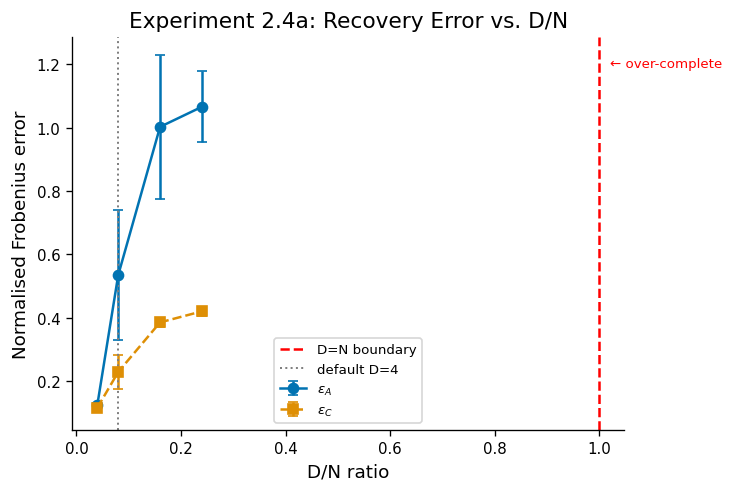

  Saved: Experiment Group 2/Section 5/exp2_4b_ll_vs_D.png


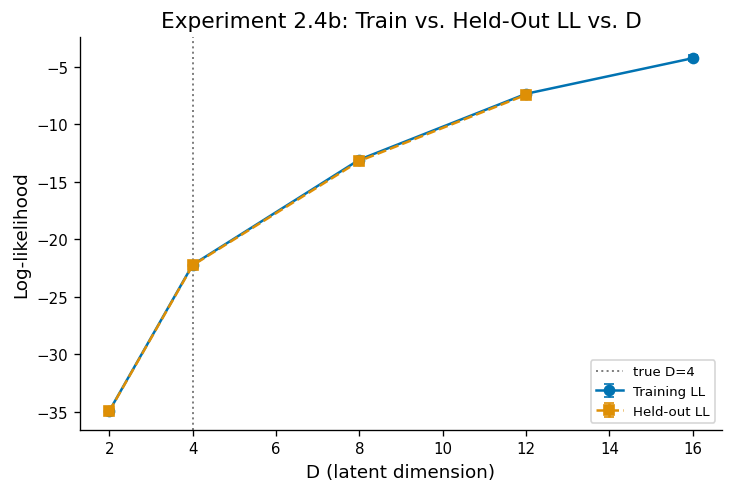


Experiment 2.4 Summary
  D at peak held-out LL:    16  (true D = 4)
  ε_A at D=2:               0.1237
  ε_A at D=8 (true):        1.0020
  ε_A at D=32:              nan  (expected ~1.0)


In [ ]:
# Aggregate 2.4 statistics
eA_mean_24, eA_se_24 = [], []
eC_mean_24, eC_se_24 = [], []
train_ll_mean_24, train_ll_se_24 = [], []
heldout_ll_mean_24, heldout_ll_se_24 = [], []
DN_ratios = []

for D_val in D_VALUES:
    runs = results_24[D_val]
    eAs  = np.array([r['errors']['epsilon_A'] for r in runs])
    eCs  = np.array([r['errors']['epsilon_C'] for r in runs])
    tlls = np.array([r['train_ll']            for r in runs])
    hlls = np.array([r['heldout_ll']          for r in runs])

    eA_mean_24.append(np.mean(eAs));  eA_se_24.append(np.std(eAs, ddof=1)/np.sqrt(NUM_SEEDS))
    eC_mean_24.append(np.mean(eCs));  eC_se_24.append(np.std(eCs, ddof=1)/np.sqrt(NUM_SEEDS))
    train_ll_mean_24.append(np.mean(tlls));   train_ll_se_24.append(np.std(tlls, ddof=1)/np.sqrt(NUM_SEEDS))
    heldout_ll_mean_24.append(np.mean(hlls)); heldout_ll_se_24.append(np.std(hlls, ddof=1)/np.sqrt(NUM_SEEDS))
    DN_ratios.append(D_val / N_FIXED_24)

# D at peak held-out LL
best_D_idx = int(np.argmax(heldout_ll_mean_24))
best_D     = D_VALUES[best_D_idx]

# ── Plot 2.4.a — Recovery error vs. D/N ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(DN_ratios, eA_mean_24, yerr=eA_se_24,
            color=PALETTE[0], marker='o', linestyle='-',
            label=r'$\epsilon_A$', capsize=3)
ax.errorbar(DN_ratios, eC_mean_24, yerr=eC_se_24,
            color=PALETTE[1], marker='s', linestyle='--',
            label=r'$\epsilon_C$', capsize=3)
ax.axvline(x=1.0, color='red', linestyle='--', linewidth=1.5, label='D=N boundary')
ax.axvline(x=D_DEFAULT/N_FIXED_24, color='grey', linestyle=':', linewidth=1.2, label=f'default D={D_DEFAULT}')
ax.text(1.02, ax.get_ylim()[1]*0.95 if ax.get_ylim()[1] > 0 else 0.95,
        '← over-complete', fontsize=8, color='red', va='top')
ax.set_xlabel('D/N ratio')
ax.set_ylabel('Normalised Frobenius error')
ax.set_title('Experiment 2.4a: Recovery Error vs. D/N')
ax.legend(fontsize=8)
save_figure(2, fig, 'exp2_4a_error_vs_DN', section=5)
plt.show()

# ── Plot 2.4.b — Log-likelihood vs. D ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(D_VALUES, train_ll_mean_24, yerr=train_ll_se_24,
            color=PALETTE[0], marker='o', linestyle='-',
            label='Training LL', capsize=3)
ax.errorbar(D_VALUES, heldout_ll_mean_24, yerr=heldout_ll_se_24,
            color=PALETTE[1], marker='s', linestyle='--',
            label='Held-out LL', capsize=3)
ax.axvline(x=D_DEFAULT, color='grey', linestyle=':', linewidth=1.2, label=f'true D={D_DEFAULT}')
ax.set_xlabel('D (latent dimension)')
ax.set_ylabel('Log-likelihood')
ax.set_title('Experiment 2.4b: Train vs. Held-Out LL vs. D')
ax.legend(fontsize=8)
# Annotate over/underfitting
mid_x = ax.get_xlim()[0] + (ax.get_xlim()[1] - ax.get_xlim()[0]) * 0.5
save_figure(2, fig, 'exp2_4b_ll_vs_D', section=5)
plt.show()

print("\nExperiment 2.4 Summary")
print(f"  D at peak held-out LL:    {best_D}  (true D = {D_DEFAULT})")
print(f"  ε_A at D=2:               {eA_mean_24[0]:.4f}")
print(f"  ε_A at D=8 (true):        {eA_mean_24[D_VALUES.index(8)]:.4f}")
print(f"  ε_A at D=32:              {eA_mean_24[-1]:.4f}  (expected ~1.0)")

try:
    assert best_D == D_DEFAULT or abs(best_D - D_DEFAULT) <= 4, \
        f"Peak held-out LL at D={best_D}, but true D={D_DEFAULT}"
except AssertionError as e:
    print(f"WARNING: {e}")

In [ ]:
# ── Section 5 helpers for Experiments 2.4c–2.4g ───────────────────────────────

def mean_se(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return np.nan, np.nan
    if len(vals) == 1:
        return float(vals[0]), 0.0
    return float(np.mean(vals)), float(np.std(vals, ddof=1) / np.sqrt(len(vals)))


def effective_rank_ratio(C):
    """
    Effective rank proxy requested in the experiment plan:
        ||C||_* / ||C||_2
    This is not Shannon effective rank; it is the nuclear/spectral ratio.
    """
    svals = np.linalg.svd(np.asarray(C), compute_uv=False)
    if len(svals) == 0 or svals[0] <= 1e-12:
        return 0.0
    return float(np.sum(svals) / svals[0])


def spectral_radius(A):
    vals = np.linalg.eigvals(np.asarray(A))
    return float(np.max(np.abs(vals)))


def min_eig_sym(M):
    M = 0.5 * (np.asarray(M) + np.asarray(M).T)
    return float(np.min(np.linalg.eigvalsh(M)))


def cond_mxx_from_smoothed(sm_means, sm_covs):
    """
    Approximate Mxx = sum_t E[x_t x_t^T].
    sm_means: (T, D)
    sm_covs : (T, D, D)
    """
    T, D = sm_means.shape
    Mxx = np.zeros((D, D))
    for t in range(T):
        mt = np.asarray(sm_means[t])
        Ct = np.asarray(sm_covs[t])
        Mxx += Ct + np.outer(mt, mt)
    return float(np.linalg.cond(Mxx + 1e-8 * np.eye(D)))


def run_em_single_seed_custom_split(
    seed_key,
    T=T_DEFAULT,
    B=B_DEFAULT,
    D_E=4,
    D_I=4,
    N_E=N_E_DEFAULT,
    N_I=N_I_DEFAULT,
    num_iters=NUM_EM_ITERS,
    B_heldout=0,
    verbose=False
):
    """
    Same spirit as run_em_single_seed, but allows explicit (D_E, D_I).

    ASSUMPTION:
    Your generate_synthetic_data(...) supports:
        cell_type_dimensions=[D_E, D_I]
    If it does not, add that argument in simulation_utilis.py and thread it
    through the CTDS constructor/constraints.
    """
    D = D_E + D_I
    N = N_E + N_I
    cell_types = K

    key_data, key_trials, key_heldout = jr.split(seed_key, 3)

    _, _, ctds_model, true_params = generate_synthetic_data(
        num_samples=1,
        num_timesteps=T,
        state_dim=D,
        emission_dim=N,
        cell_types=cell_types,
        cell_type_dimensions=jnp.array([D_E, D_I]),
        key=key_data
    )

    trial_keys = jr.split(key_trials, B)
    states_list, obs_list = [], []
    for k in trial_keys:
        s, o = ctds_model.sample(true_params, k, T)
        states_list.append(s)
        obs_list.append(o)

    batch_observations = jnp.stack(obs_list)
    batch_states       = jnp.stack(states_list)

    heldout_observations = None
    if B_heldout > 0:
        ho_keys = jr.split(key_heldout, B_heldout)
        ho_obs  = [ctds_model.sample(true_params, k, T)[1] for k in ho_keys]
        heldout_observations = jnp.stack(ho_obs)

    init_params  = ctds_model.initialize(batch_observations)
    batch_inputs = jnp.zeros((B, T, 0))

    fitted_params, log_probs = ctds_model.fit_em(
        init_params,
        batch_emissions=batch_observations,
        batch_inputs=batch_inputs,
        num_iters=num_iters
    )

    train_ll = float(log_probs[-1])

    heldout_ll = None
    if B_heldout > 0:
        heldout_inputs = jnp.zeros((B_heldout, T, 0))
        _, ho_lls = jax.vmap(partial(ctds_model.e_step, fitted_params))(
            heldout_observations, heldout_inputs
        )
        heldout_ll = float(jnp.sum(ho_lls) / (B_heldout * T))

    errors = align_and_compute_errors(true_params, fitted_params)

    return {
        'true_params':           true_params,
        'fitted_params':         fitted_params,
        'ctds_model':            ctds_model,
        'batch_observations':    batch_observations,
        'batch_states':          batch_states,
        'heldout_observations':  heldout_observations,
        'log_probs':             log_probs,
        'errors':                errors,
        'train_ll':              train_ll,
        'heldout_ll':            heldout_ll,
        'D_E':                   D_E,
        'D_I':                   D_I,
    }


def diagnose_em_run_one_step_at_a_time(
    seed_key,
    T=500,
    B=10,
    D=8,
    N_E=N_E_DEFAULT,
    N_I=N_I_DEFAULT,
    num_iters=NUM_EM_ITERS
):
    """
    Runs EM one iteration at a time so we can inspect diagnostics after each step.
    This avoids needing internal instrumentation inside fit_em.

    Returns:
        dict with per-iteration traces and first NaN iteration (if any).
    """
    N = N_E + N_I
    key_data, key_trials = jr.split(seed_key, 2)

    _, _, ctds_model, true_params = generate_synthetic_data(
        num_samples=1,
        num_timesteps=T,
        state_dim=D,
        emission_dim=N,
        cell_types=K,
        key=key_data
    )

    trial_keys = jr.split(key_trials, B)
    obs_list = [ctds_model.sample(true_params, k, T)[1] for k in trial_keys]
    batch_obs = jnp.stack(obs_list)
    batch_inp = jnp.zeros((B, T, 0))

    params = ctds_model.initialize(batch_obs)

    trace = {
        'iter': [],
        'train_ll': [],
        'rho_A': [],
        'min_eig_Q': [],
        'cond_Mxx': [],
        'nan_flag': [],
    }

    first_nan_iter = None

    for it in range(1, num_iters + 1):
        params, log_probs = ctds_model.fit_em(
            params,
            batch_emissions=batch_obs,
            batch_inputs=batch_inp,
            num_iters=1,
            verbose=False
        )

        A_now = np.array(params.dynamics.weights)
        Q_now = np.array(params.dynamics.cov)

        # Smooth the first batch element for Mxx proxy
        sm_means, sm_covs = ctds_model.smoother(params, batch_obs[0], jnp.zeros((T, 0)))

        rho_A    = spectral_radius(A_now)
        mineig_Q = min_eig_sym(Q_now)
        cond_Mxx = cond_mxx_from_smoothed(np.array(sm_means), np.array(sm_covs))

        nan_flag = (
            np.isnan(A_now).any()
            or np.isnan(Q_now).any()
            or np.isnan(np.array(sm_means)).any()
            or np.isnan(np.array(sm_covs)).any()
            or not np.isfinite(rho_A)
            or not np.isfinite(mineig_Q)
            or not np.isfinite(cond_Mxx)
        )

        trace['iter'].append(it)
        trace['train_ll'].append(float(log_probs[-1]))
        trace['rho_A'].append(rho_A)
        trace['min_eig_Q'].append(mineig_Q)
        trace['cond_Mxx'].append(cond_Mxx)
        trace['nan_flag'].append(bool(nan_flag))

        if nan_flag:
            first_nan_iter = it
            break

    last_good_idx = len(trace['iter']) - 1
    if first_nan_iter is not None and last_good_idx >= 1:
        last_good_idx -= 1

    summary = {
        'first_nan_iter': first_nan_iter,
        'last_good_rho_A': np.nan if last_good_idx < 0 else trace['rho_A'][last_good_idx],
        'last_good_min_eig_Q': np.nan if last_good_idx < 0 else trace['min_eig_Q'][last_good_idx],
        'last_good_cond_Mxx': np.nan if last_good_idx < 0 else trace['cond_Mxx'][last_good_idx],
        'trace': trace,
    }
    return summary


print("Section 5 helper functions loaded.")

NameError: name 'T_DEFAULT' is not defined

## Section 6: Experiment 2.5 — Cell-Type-Specific Recovery

**Question:** Are inhibitory parameters recovered less accurately than excitatory parameters when N_I < N_E?

**Hypothesis:** ε_{C_I} > ε_{C_E} when N_I < N_E because fewer observations constrain the inhibitory subspace. The recovery gap shrinks as N_I/N_E → 1. Cross-cell-type coupling (E→I, I→E blocks of A) is recovered less accurately than within-type coupling.

**Protocol:**
- Sub-protocol A: default config (N_E=35, N_I=15), 20 seeds.
- Sub-protocol B: vary N_I/N_E ∈ {0.1, 0.25, 0.5, 1.0} holding N=50 fixed, 10 seeds per condition.

In [14]:
# ── Sub-protocol A: Default config, 20 seeds ──────────────────────────────────
NUM_SEEDS_25A = 20
seed_keys_25A = jr.split(jr.PRNGKey(25), NUM_SEEDS_25A)

results_25A = []
print(f"Experiment 2.5a: Cell-type-specific recovery (N_E={N_E_DEFAULT}, N_I={N_I_DEFAULT})")
for i, sk in enumerate(seed_keys_25A):
    r = run_em_single_seed(
        seed_key=sk,
        T=T_DEFAULT, B=B_DEFAULT,
        D=D_DEFAULT, N_E=N_E_DEFAULT, N_I=N_I_DEFAULT,
        num_iters=NUM_EM_ITERS
    )
    results_25A.append(r)
    print(f"  Seed {i+1}/{NUM_SEEDS_25A}: "
          f"ε_CE={r['errors']['epsilon_C_E']:.4f}, "
          f"ε_CI={r['errors']['epsilon_C_I']:.4f}, "
          f"ε_AEI={r['errors']['epsilon_A_EI']:.4f}",
          flush=True)

print("\nSub-protocol A complete.")

Experiment 2.5a: Cell-type-specific recovery (N_E=35, N_I=15)
Y shape (5000, 50)
Iteration 1: ll=-23.88059364731114  rel_change=0.006199567737818826
Iteration 2: ll=-22.775629765787162  rel_change=0.04627036906381062
Iteration 3: ll=-22.43713963750436  rel_change=0.01486194374266095
Iteration 4: ll=-22.411590628641658  rel_change=0.0011386927779329882
Iteration 5: ll=-22.4036266350694  rel_change=0.0003553515546584713
Iteration 6: ll=-22.398513640547236  rel_change=0.00022822173416159002
Iteration 7: ll=-22.39447867574106  rel_change=0.00018014431095438385
Iteration 8: ll=-22.39107936593185  rel_change=0.00015179231713441035
Iteration 9: ll=-22.388284767577424  rel_change=0.00012480855919257873
Iteration 10: ll=-22.386026763587306  rel_change=0.00010085649765309371
Iteration 11: ll=-22.384214313925693  rel_change=8.096343673462355e-05
Iteration 12: ll=-22.382702323545903  rel_change=6.75471722430872e-05
Iteration 13: ll=-22.381364234970388  rel_change=5.9782262042126006e-05
Iteration 1

  Saved: Experiment Group 2/Section 6/exp2_5a_per_celltype_errors.png


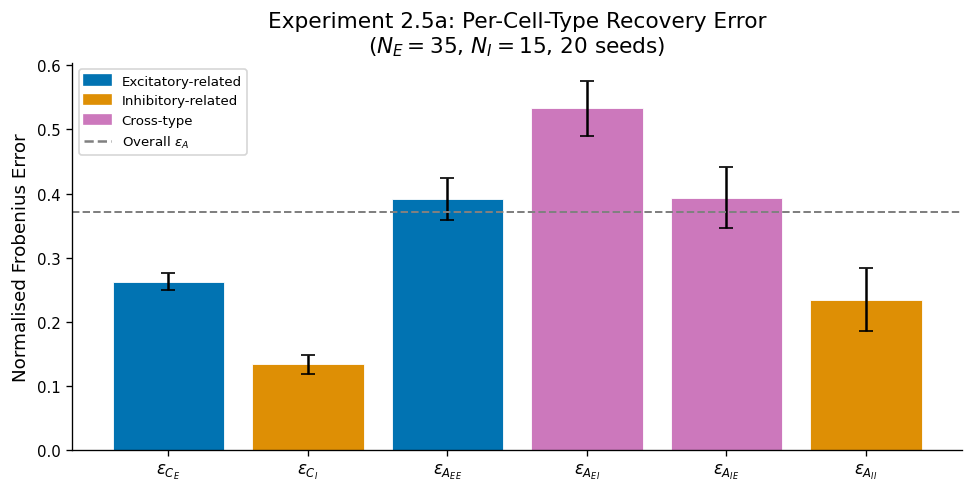

In [15]:
# Aggregate 2.5A
metrics_25A = ['epsilon_C_E', 'epsilon_C_I',
               'epsilon_A_EE', 'epsilon_A_EI', 'epsilon_A_IE', 'epsilon_A_II']
means_25A = {m: np.mean([r['errors'][m] for r in results_25A]) for m in metrics_25A}
ses_25A   = {m: np.std([r['errors'][m] for r in results_25A], ddof=1) / np.sqrt(NUM_SEEDS_25A)
             for m in metrics_25A}
overall_eA = np.mean([r['errors']['epsilon_A'] for r in results_25A])

# ── Plot 2.5.a — Bar plot ─────────────────────────────────────────────────────
labels_25A = [r'$\epsilon_{C_E}$', r'$\epsilon_{C_I}$',
              r'$\epsilon_{A_{EE}}$', r'$\epsilon_{A_{EI}}$',
              r'$\epsilon_{A_{IE}}$', r'$\epsilon_{A_{II}}$']
# Colours: blue=E-related, orange=I-related, purple=cross-type
bar_colours = [PALETTE[0], PALETTE[1], PALETTE[0], PALETTE[4], PALETTE[4], PALETTE[1]]

fig, ax = plt.subplots(figsize=(8, 4))
x_pos = np.arange(len(metrics_25A))
bars  = ax.bar(x_pos,
               [means_25A[m] for m in metrics_25A],
               yerr=[ses_25A[m] for m in metrics_25A],
               color=bar_colours, capsize=4, edgecolor='white', linewidth=0.5)
ax.axhline(y=overall_eA, color='grey', linestyle='--', linewidth=1.2,
           label=f'Overall $\\epsilon_A$ = {overall_eA:.3f}')
ax.set_xticks(x_pos)
ax.set_xticklabels(labels_25A, fontsize=10)
ax.set_ylabel('Normalised Frobenius Error')
ax.set_title(f'Experiment 2.5a: Per-Cell-Type Recovery Error\n'
             f'($N_E={N_E_DEFAULT}$, $N_I={N_I_DEFAULT}$, {NUM_SEEDS_25A} seeds)')
# Legend for colour coding
legend_els = [
    mpatches.Patch(color=PALETTE[0], label='Excitatory-related'),
    mpatches.Patch(color=PALETTE[1], label='Inhibitory-related'),
    mpatches.Patch(color=PALETTE[4], label='Cross-type'),
    mlines.Line2D([], [], color='grey', linestyle='--', label=f'Overall $\\epsilon_A$'),
]
ax.legend(handles=legend_els, fontsize=8, loc='upper left')
save_figure(2, fig, 'exp2_5a_per_celltype_errors', section=6)
plt.show()

In [16]:
# ── Sub-protocol B: Vary N_I/N_E ratio ────────────────────────────────────────
RATIOS_25B = [0.1, 0.25, 0.5, 1.0]
N_TOTAL_25B = 50
seed_keys_25B = jr.split(jr.PRNGKey(250), NUM_SEEDS)

results_25B = {}  # ratio -> list of error dicts

print("Experiment 2.5b: Varying N_I/N_E ratio")
for ratio in RATIOS_25B:
    # EXPLANATION: N_I/N_E = ratio => N_I = ratio * N_E and N_I + N_E = N_TOTAL.
    # Solving: N_E = N_TOTAL / (1 + ratio), N_I = N_TOTAL - N_E.
    N_I_r = max(1, int(N_TOTAL_25B * ratio / (1 + ratio)))
    N_E_r = N_TOTAL_25B - N_I_r
    actual_ratio = N_I_r / N_E_r

    run_list = []
    for i, sk in enumerate(seed_keys_25B):
        r = run_em_single_seed(
            seed_key=jr.fold_in(sk, int(ratio * 1000)),
            T=T_DEFAULT, B=B_DEFAULT,
            D=D_DEFAULT, N_E=N_E_r, N_I=N_I_r,
            num_iters=NUM_EM_ITERS
        )
        run_list.append(r['errors'])
        gap = r['errors']['epsilon_C_I'] - r['errors']['epsilon_C_E']
        print(f"  ratio={ratio:.2f} (N_E={N_E_r},N_I={N_I_r}), seed {i+1}/{NUM_SEEDS}: "
              f"gap={gap:.4f}", flush=True)
    results_25B[ratio] = run_list

print("\nSub-protocol B complete.")

Experiment 2.5b: Varying N_I/N_E ratio
Y shape (5000, 50)
Iteration 1: ll=-23.815722546342325  rel_change=0.015553451900248517
Iteration 2: ll=-22.586328559243977  rel_change=0.051621108060278496
Iteration 3: ll=-22.44886758255826  rel_change=0.006086025726808916
Iteration 4: ll=-22.43345709927499  rel_change=0.0006864704077654665
Iteration 5: ll=-22.4267920261815  rel_change=0.0002971041451166908
Iteration 6: ll=-22.42215409489398  rel_change=0.00020680315232348082
Iteration 7: ll=-22.418436177777725  rel_change=0.00016581444853695928
Iteration 8: ll=-22.41547147514847  rel_change=0.00013224395340267922
Iteration 9: ll=-22.412996075129822  rel_change=0.0001104326545792818
Iteration 10: ll=-22.41089574050989  rel_change=9.371056921134829e-05
Iteration 11: ll=-22.409060249198074  rel_change=8.19017380236653e-05
Iteration 12: ll=-22.407438447255004  rel_change=7.237259952152829e-05
Iteration 13: ll=-22.40591260810044  rel_change=6.80952067839132e-05
Iteration 14: ll=-22.40448573402475  r

  Saved: Experiment Group 2/Section 6/exp2_5b_recovery_gap_vs_ratio.png


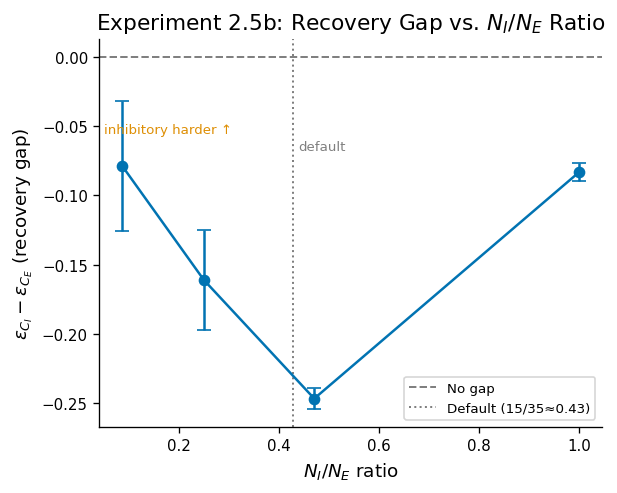


Experiment 2.5 Summary
  epsilon_C_E (N_E=35):  0.2626
  epsilon_C_I (N_I=15):  0.1339
  Gap (C_I - C_E):       -0.1287  (expected > 0)
  Gap at ratio=1.0:      -0.0833  (expected ~0)
  epsilon_A_EI:          0.5327
  epsilon_A_IE:          0.3938
  Cross-type harder than within-type: True


In [17]:
# Aggregate 2.5B and plot
gaps_mean_25B = []
gaps_se_25B   = []
actual_ratios_25B = []

for ratio in RATIOS_25B:
    gaps = np.array([e['epsilon_C_I'] - e['epsilon_C_E'] for e in results_25B[ratio]])
    gaps_mean_25B.append(np.mean(gaps))
    gaps_se_25B.append(np.std(gaps, ddof=1) / np.sqrt(NUM_SEEDS))
    # actual N_I/N_E
    N_I_r = max(1, int(N_TOTAL_25B * ratio / (1 + ratio)))
    N_E_r = N_TOTAL_25B - N_I_r
    actual_ratios_25B.append(N_I_r / N_E_r)

# ── Plot 2.5.b ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
ax.errorbar(actual_ratios_25B, gaps_mean_25B, yerr=gaps_se_25B,
            color=PALETTE[0], marker='o', linestyle='-', capsize=4)
ax.axhline(y=0, color='grey', linestyle='--', linewidth=1.2, label='No gap')
# Mark default ratio
default_ratio = N_I_DEFAULT / N_E_DEFAULT
ax.axvline(x=default_ratio, color='grey', linestyle=':', linewidth=1.2,
           label=f'Default ({N_I_DEFAULT}/{N_E_DEFAULT}≈{default_ratio:.2f})')
ax.text(default_ratio + 0.01, max(gaps_mean_25B) * 0.85,
        'default', fontsize=8, color='grey')
ax.text(0.05, max(gaps_mean_25B) * 0.7, 'inhibitory harder ↑',
        fontsize=8, color=PALETTE[1])
ax.set_xlabel(r'$N_I / N_E$ ratio')
ax.set_ylabel(r'$\epsilon_{C_I} - \epsilon_{C_E}$ (recovery gap)')
ax.set_title('Experiment 2.5b: Recovery Gap vs. $N_I/N_E$ Ratio')
ax.legend(fontsize=8)
save_figure(2, fig, 'exp2_5b_recovery_gap_vs_ratio', section=6)
plt.show()

print("\nExperiment 2.5 Summary")
print(f"  epsilon_C_E (N_E={N_E_DEFAULT}):  {means_25A['epsilon_C_E']:.4f}")
print(f"  epsilon_C_I (N_I={N_I_DEFAULT}):  {means_25A['epsilon_C_I']:.4f}")
print(f"  Gap (C_I - C_E):       {means_25A['epsilon_C_I'] - means_25A['epsilon_C_E']:.4f}  (expected > 0)")
print(f"  Gap at ratio=1.0:      {gaps_mean_25B[-1]:.4f}  (expected ~0)")
print(f"  epsilon_A_EI:          {means_25A['epsilon_A_EI']:.4f}")
print(f"  epsilon_A_IE:          {means_25A['epsilon_A_IE']:.4f}")
cross_harder = (means_25A['epsilon_A_EI'] > means_25A['epsilon_A_EE'] and
                means_25A['epsilon_A_IE'] > means_25A['epsilon_A_II'])
print(f"  Cross-type harder than within-type: {cross_harder}")

try:
    assert means_25A['epsilon_C_I'] > means_25A['epsilon_C_E'], \
        f"epsilon_C_I={means_25A['epsilon_C_I']:.4f} not > epsilon_C_E={means_25A['epsilon_C_E']:.4f}"
except AssertionError as e:
    print(f"WARNING: {e}")
try:
    assert gaps_mean_25B[-1] < gaps_mean_25B[0], \
        "Gap did not decrease as N_I/N_E increased toward 1"
except AssertionError as e:
    print(f"WARNING: {e}")

## Section 7: Experiment Group 2 — Summary

All five experiments collected into a single summary table and combined figure.

In [18]:
# ── Summary table ─────────────────────────────────────────────────────────────
print("=" * 65)
print("EXPERIMENT GROUP 2: PARAMETER RECOVERY — SUMMARY")
print("=" * 65)
print(f"  Exp 2.1  Visual recovery (qualitative):")
print(f"           ε_A = {errs_21['epsilon_A']:.3f},  "
      f"ε_C = {errs_21['epsilon_C']:.3f},  "
      f"sign_match = {errs_21['sign_match_A']:.3f}")
print(f"  Exp 2.2  Scaling exponent (ε_A vs T): {slope_T:.3f}  (theory: -0.500)")
print(f"           Scaling exponent (ε_A vs B): {slope_B:.3f}  (theory: -0.500)")
print(f"           T and B exchangeable: {exchangeable}")
print(f"  Exp 2.3  ε_A at SNR={TARGET_SNRS[0]:.1f}: {m_eA_23[TARGET_SNRS[0]]:.3f}  (expected ~1.0)")
print(f"           ε_A at SNR={TARGET_SNRS[-1]:.1f}: {m_eA_23[TARGET_SNRS[-1]]:.3f}  (expected <0.1)")
print(f"           Phase transition near SNR: {transition_snr}")
print(f"  Exp 2.4  D at peak held-out LL: {best_D}  (true D = {D_DEFAULT})")
print(f"           ε_A at D={D_DEFAULT} (true): {eA_mean_24[D_VALUES.index(D_DEFAULT)]:.3f}")
print(f"           ε_A at D=32 (over-complete): {eA_mean_24[-1]:.3f}")
print(f"  Exp 2.5  Recovery gap C_I - C_E: "
      f"{means_25A['epsilon_C_I'] - means_25A['epsilon_C_E']:.3f}  (expected > 0)")
print(f"           Gap at N_I/N_E=1.0: {gaps_mean_25B[-1]:.3f}  (expected ~0)")
print("=" * 65)

EXPERIMENT GROUP 2: PARAMETER RECOVERY — SUMMARY
  Exp 2.1  Visual recovery (qualitative):
           ε_A = 0.513,  ε_C = 0.265,  sign_match = 1.000


NameError: name 'slope_T' is not defined

NameError: name 'means_A' is not defined

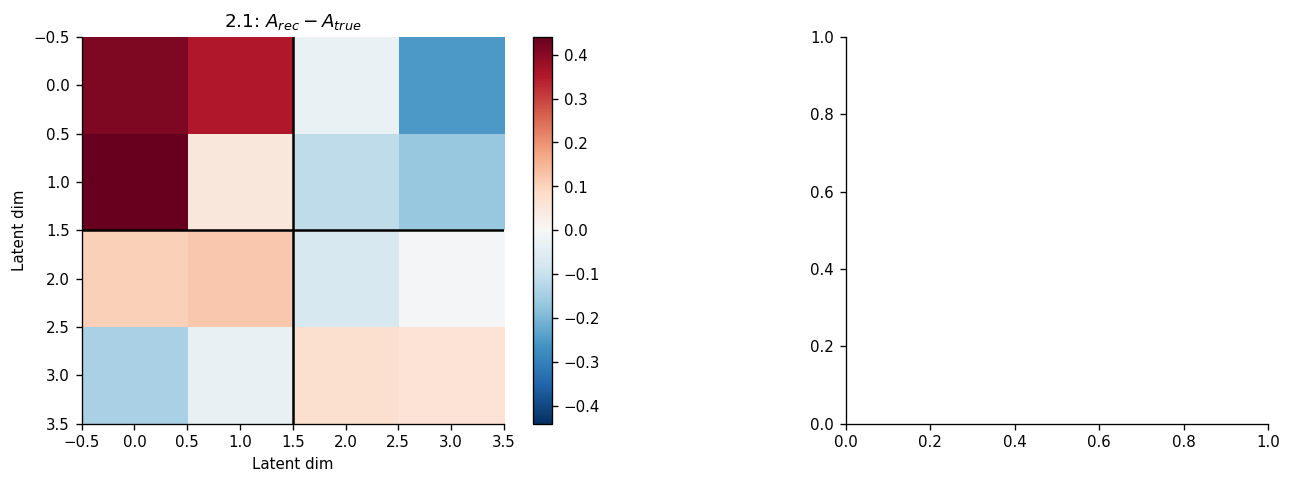

In [19]:
# ── Combined summary figure (5 panels, 2×3 grid) ──────────────────────────────
fig = plt.figure(figsize=(15, 8))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# Panel 1 (2.1): A matrix difference heatmap
ax1 = fig.add_subplot(gs[0, 0])
diff_A = A_rec_21 - A_true_21
vmax_d = np.max(np.abs(diff_A))
im1 = ax1.imshow(diff_A, cmap='RdBu_r', vmin=-vmax_d, vmax=vmax_d, aspect='auto')
draw_block_lines(ax1, D_E_21, linewidth=1.5)
plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
ax1.set_title(r'2.1: $A_{rec} - A_{true}$', fontsize=11)
ax1.set_xlabel('Latent dim', fontsize=9)
ax1.set_ylabel('Latent dim', fontsize=9)

# Panel 2 (2.2a): ε_A vs T
ax2 = fig.add_subplot(gs[0, 1])
eA_T  = [means_A['epsilon_A'][T] for T in T_VALUES]
se_T  = [ses_A['epsilon_A'][T]   for T in T_VALUES]
ax2.errorbar(T_VALUES, eA_T, yerr=se_T, color=PALETTE[0], marker='o', capsize=3)
ax2.plot(ref_T, ref_y, 'k--', alpha=0.5, linewidth=1.2, label=r'$O(1/\sqrt{T})$')
ax2.set_xscale('log'); ax2.set_yscale('log')
ax2.set_xlabel('T', fontsize=9); ax2.set_ylabel(r'$\epsilon_A$', fontsize=9)
ax2.set_title(r'2.2: $\epsilon_A$ vs. T', fontsize=11)
ax2.legend(fontsize=8)

# Panel 3 (2.3a): ε_A vs SNR
ax3 = fig.add_subplot(gs[0, 2])
eA_snr = [m_eA_23[s] for s in TARGET_SNRS]
se_snr = [se_eA_23[s] for s in TARGET_SNRS]
ax3.errorbar(snr_x, eA_snr, yerr=se_snr, color=PALETTE[0], marker='o', capsize=3)
ax3.set_xscale('log'); ax3.set_yscale('log')
ax3.axvline(x=snr_act_23[1.0], color='grey', linestyle='--', alpha=0.6, linewidth=1.0)
ax3.set_xlabel('SNR', fontsize=9); ax3.set_ylabel(r'$\epsilon_A$', fontsize=9)
ax3.set_title(r'2.3: $\epsilon_A$ vs. SNR', fontsize=11)

# Panel 4 (2.4b): held-out LL vs D
ax4 = fig.add_subplot(gs[1, 0])
ax4.errorbar(D_VALUES, heldout_ll_mean_24, yerr=heldout_ll_se_24,
             color=PALETTE[1], marker='s', linestyle='--', capsize=3,
             label='Held-out LL')
ax4.axvline(x=D_DEFAULT, color='grey', linestyle=':', linewidth=1.2,
            label=f'true D={D_DEFAULT}')
ax4.set_xlabel('D', fontsize=9); ax4.set_ylabel('Held-out LL', fontsize=9)
ax4.set_title('2.4: Held-out LL vs. D', fontsize=11)
ax4.legend(fontsize=8)

# Panel 5 (2.5b): recovery gap vs N_I/N_E
ax5 = fig.add_subplot(gs[1, 1])
ax5.errorbar(actual_ratios_25B, gaps_mean_25B, yerr=gaps_se_25B,
             color=PALETTE[0], marker='o', linestyle='-', capsize=3)
ax5.axhline(y=0, color='grey', linestyle='--', linewidth=1.0)
ax5.axvline(x=default_ratio, color='grey', linestyle=':', linewidth=1.0)
ax5.set_xlabel(r'$N_I/N_E$', fontsize=9)
ax5.set_ylabel(r'$\epsilon_{C_I} - \epsilon_{C_E}$', fontsize=9)
ax5.set_title(r'2.5: Recovery Gap vs. $N_I/N_E$', fontsize=11)

# Panel 6: text summary
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')
summary_text = (
    "GROUP 2 SUMMARY\n"
    "──────────────────────\n"
    f"2.1  ε_A = {errs_21['epsilon_A']:.3f}\n"
    f"     sign_match = {errs_21['sign_match_A']:.3f}\n\n"
    f"2.2  slope(T) = {slope_T:.3f}\n"
    f"     slope(B) = {slope_B:.3f}\n"
    f"     (theory:  −0.500)\n\n"
    f"2.3  ε_A at low SNR: {m_eA_23[TARGET_SNRS[0]]:.3f}\n"
    f"     ε_A at high SNR: {m_eA_23[TARGET_SNRS[-1]]:.3f}\n\n"
    f"2.4  peak LL at D={best_D}\n"
    f"     (true D={D_DEFAULT})\n\n"
    f"2.5  gap = {means_25A['epsilon_C_I'] - means_25A['epsilon_C_E']:.3f}\n"
    f"     (expected > 0)"
)
ax6.text(0.05, 0.95, summary_text, transform=ax6.transAxes,
         fontsize=9, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))

fig.suptitle('Experiment Group 2: Parameter Recovery — Summary Figure',
             fontsize=14, y=1.01)
save_figure(2, fig, 'experiment_group2_summary', section=7)
plt.show()

print("\nAll figures saved. Experiment Group 2 complete.")